In [1]:
# import libraries
import math
import os
import pickle
import random
import time
import itertools
import importlib

# import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn import preprocessing

import torch
import scipy
import scipy.io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# import Koopman Libraries
from core.koopman_core_linear_GPU import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
from core.util import fit_standardizer
from models.koop_model import model_matricies, lift_raw, lift_scaled

# ===== import Frenet-real-state dynamics file =====
import dynamics.cacalv3 as cacalv3

importlib.reload(cacalv3)
from dynamics.cacalv3 import FK_solver, single_vehicle_data_gen_multi

# control
from control_files.nmpc_osqp_ppc import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics import linear_Dynamics

Using device: cuda
GPU: NVIDIA GeForce RTX 5080


In [2]:

# =============================================================================
# 全局配置（所有功能都可以开关）
# =============================================================================
RUN_CFG = {
    "seed": 2026,
    "enable_koopman_training": True,
    "enable_koopman_linear_refit": True,
    "enable_four_vehicle": True,
    "enable_curved_tracking": True,
    "enable_adaptive_weight_matrix": True,
    "enable_ppc_soft_constraints": True,
    "enable_dynamic_ppc": True,
    "enable_cooperative_transport": True,
    "enable_solver_guard": True,
}

KOOPMAN_CFG = {
    "encoder_hidden_width": 96,
    "encoder_hidden_depth": 4,
    "encoder_output_dim": 20,
    "lr": 3e-4,
    "epochs": 140,
    "batch_size": 4096,
    "weight_decay": 8e-5,
    "ridge_lambda": 5e-5,
    "linear_fit_blend": 0.60,
    "previous_model_blend": 0.20,
    "deterministic_training": True,
}

MPC_CFG = {
    "path_length": 60.0,
    "horizon": 32,
    "max_sqp_iters": 2,
    "ff_gain": 0.75,
    "delta_alpha": 0.60,
    "ax_alpha": 0.50,
    "weight_smoothing": 0.80,
    "weight_rate_limit": 0.22,
    "osqp_time_limit": 0.05,
}

PPC_CFG = {
    "rho_ey_0": 0.45,
    "rho_ey_inf": 0.035,
    "lambda_ey": 1.25,
    "rho_epsi_0": 0.22,
    "rho_epsi_inf": 0.025,
    "lambda_epsi": 1.35,
    "curvature_gain": 0.45,
    "curvature_norm": 0.080,
}

FORMATION_CFG = {
    "leader_index": 0,
    "k_s": 0.08,
    "k_vx": 0.10,
    "k_ey": 0.65,
    "k_epsi": 0.25,
}


def set_global_seed(seed, deterministic=False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = bool(deterministic)
    torch.backends.cudnn.benchmark = not bool(deterministic)
    torch.use_deterministic_algorithms(bool(deterministic), warn_only=True)


set_global_seed(RUN_CFG["seed"], deterministic=KOOPMAN_CFG["deterministic_training"])
print("功能开关:", RUN_CFG)


功能开关: {'seed': 2026, 'enable_koopman_training': True, 'enable_koopman_linear_refit': True, 'enable_four_vehicle': True, 'enable_curved_tracking': True, 'enable_adaptive_weight_matrix': True, 'enable_ppc_soft_constraints': True, 'enable_dynamic_ppc': True, 'enable_cooperative_transport': True, 'enable_solver_guard': True}


In [3]:

# ===== helper for Frenet path =====
def build_test_frenet_path_from_xy(x_ref_path, y_ref_path):
    dx_seg = np.diff(x_ref_path)
    dy_seg = np.diff(y_ref_path)
    ds_seg = np.sqrt(dx_seg ** 2 + dy_seg ** 2)
    s_ref = np.concatenate(([0.0], np.cumsum(ds_seg)))

    dx = np.gradient(x_ref_path)
    dy = np.gradient(y_ref_path)
    psi_ref = np.unwrap(np.arctan2(dy, dx))

    ds = np.gradient(s_ref)
    curvature_ref = np.gradient(psi_ref) / np.maximum(ds, 1e-8)
    curvature_ref = np.nan_to_num(curvature_ref)

    return s_ref, psi_ref, curvature_ref


# ===== Frenet -> Cartesian for plotting =====
def frenet_to_global(s_arr, ey_arr, s_ref_path, x_ref_path, y_ref_path, psi_ref_path):
    x_center = np.interp(s_arr, s_ref_path, x_ref_path)
    y_center = np.interp(s_arr, s_ref_path, y_ref_path)
    psi_center = np.interp(s_arr, s_ref_path, psi_ref_path)

    x_global = x_center - ey_arr * np.sin(psi_center)
    y_global = y_center + ey_arr * np.cos(psi_center)
    return x_global, y_global


def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.array(x)


def scale_state(x_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(x_raw).reshape(1, -1)).flatten()


def scale_state_batch(X_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(X_raw))


def decode_scaled_to_raw(x_scaled, standardizer_x):
    return standardizer_x.inverse_transform(np.asarray(x_scaled).reshape(1, -1)).flatten()


def clip_closed_loop_state(x, s_upper=500.0):
    x = np.asarray(x, dtype=float).copy()
    x[0] = np.clip(x[0], 0.0, s_upper)  # s
    x[1] = np.clip(x[1], -5.0, 5.0)  # e_y
    x[2] = np.clip(x[2], -1.2, 1.2)  # e_psi
    x[3] = np.clip(x[3], 0.5, 8.0)  # v_x
    x[4] = np.clip(x[4], -4.0, 4.0)  # v_y
    x[5] = np.clip(x[5], -3.0, 3.0)  # r
    return x


def is_finite_vector(x):
    x = np.asarray(x, dtype=float)
    return np.all(np.isfinite(x))


def safe_FK_step(x, u, pars, SNR_DB, i, fallback_state=None, verbose=False):
    """
    对 FK_solver 做保护：
    - 若求解结果非有限，则回退到 fallback_state 或当前状态
    - 输出统一做 clip
    """
    try:
        x_next = FK_solver(
            x, u, pars,
            sensor_noise=False,
            SNR_DB=SNR_DB,
            i=i
        )
    except Exception as e:
        if verbose:
            print(f"FK_solver exception at step {i}: {e}")
        if fallback_state is None:
            fallback_state = np.asarray(x, dtype=float).copy()
        return clip_closed_loop_state(fallback_state)

    if not is_finite_vector(x_next):
        if verbose:
            print(f"Non-finite FK_solver output at step {i}")
            print("x =", x)
            print("u =", u)
            print("x_next =", x_next)
        if fallback_state is None:
            fallback_state = np.asarray(x, dtype=float).copy()
        return clip_closed_loop_state(fallback_state)

    return clip_closed_loop_state(x_next)


# ===== Koopman 线性重拟合（可开关） =====
def _lift_batch_with_net(net, x_scaled, batch_size=8192):
    z_chunks = []
    net.eval()
    with torch.no_grad():
        for i in range(0, x_scaled.shape[0], batch_size):
            xb = torch.from_numpy(x_scaled[i:i + batch_size]).float().to(net.device)
            zb = net.lift(xb).detach().cpu().numpy()
            z_chunks.append(zb)
    return np.vstack(z_chunks)


def fit_koopman_linear_matrices(model, xs_data, us_data, ridge_lambda=1e-5, batch_size=8192):
    if xs_data is None or us_data is None:
        raise ValueError("fit_koopman_linear_matrices requires xs_data and us_data")

    net = model.net
    t_eff = min(xs_data.shape[1] - 1, us_data.shape[1])

    x_curr = xs_data[:, :t_eff, :].reshape(-1, xs_data.shape[2])
    x_next = xs_data[:, 1:t_eff + 1, :].reshape(-1, xs_data.shape[2])
    u_curr = us_data[:, :t_eff, :].reshape(-1, us_data.shape[2])

    if net.standardizer_x is not None:
        x_curr_scaled = net.standardizer_x.transform(x_curr)
        x_next_scaled = net.standardizer_x.transform(x_next)
    else:
        x_curr_scaled = x_curr
        x_next_scaled = x_next

    if net.standardizer_u is not None:
        u_curr_scaled = net.standardizer_u.transform(u_curr)
    else:
        u_curr_scaled = u_curr

    z_curr = _lift_batch_with_net(net, x_curr_scaled.astype(np.float32), batch_size=batch_size)
    z_next = _lift_batch_with_net(net, x_next_scaled.astype(np.float32), batch_size=batch_size)

    phi = np.hstack([z_curr, u_curr_scaled]).astype(np.float64)
    z_next64 = z_next.astype(np.float64)

    eye = np.eye(phi.shape[1], dtype=np.float64)
    theta = np.linalg.solve(phi.T @ phi + ridge_lambda * eye, phi.T @ z_next64)

    nz = z_curr.shape[1]
    A_fit = theta[:nz, :].T
    B_fit = theta[nz:, :].T

    if getattr(net, "first_obs_const", False):
        A_fit[0, :] = 0.0
        A_fit[0, 0] = 1.0
        B_fit[0, :] = 0.0

    z_pred = phi @ theta
    rmse = float(np.sqrt(np.mean((z_pred - z_next64) ** 2)))
    return A_fit.astype(np.float32), B_fit.astype(np.float32), {"lifted_rmse": rmse, "samples": int(phi.shape[0])}


def blend_matrix(base_mat, new_mat, blend_ratio):
    beta = float(np.clip(blend_ratio, 0.0, 1.0))
    return ((1.0 - beta) * base_mat + beta * new_mat).astype(np.float32)


def summarize_solver_status(status_list):
    if not status_list:
        return {}
    values, counts = np.unique(np.array(status_list, dtype=object), return_counts=True)
    return {str(v): int(c) for v, c in zip(values, counts)}


正在生成覆盖60m高曲率双移线边界条件的多场景数据...
X shape: (450, 1400, 6)
X_changed shape: (450, 1400, 6)
U shape: (450, 1399, 2)
离线数据已保存: saved_data/single_vehicle/offline_dataset_60m_highcurv.npz


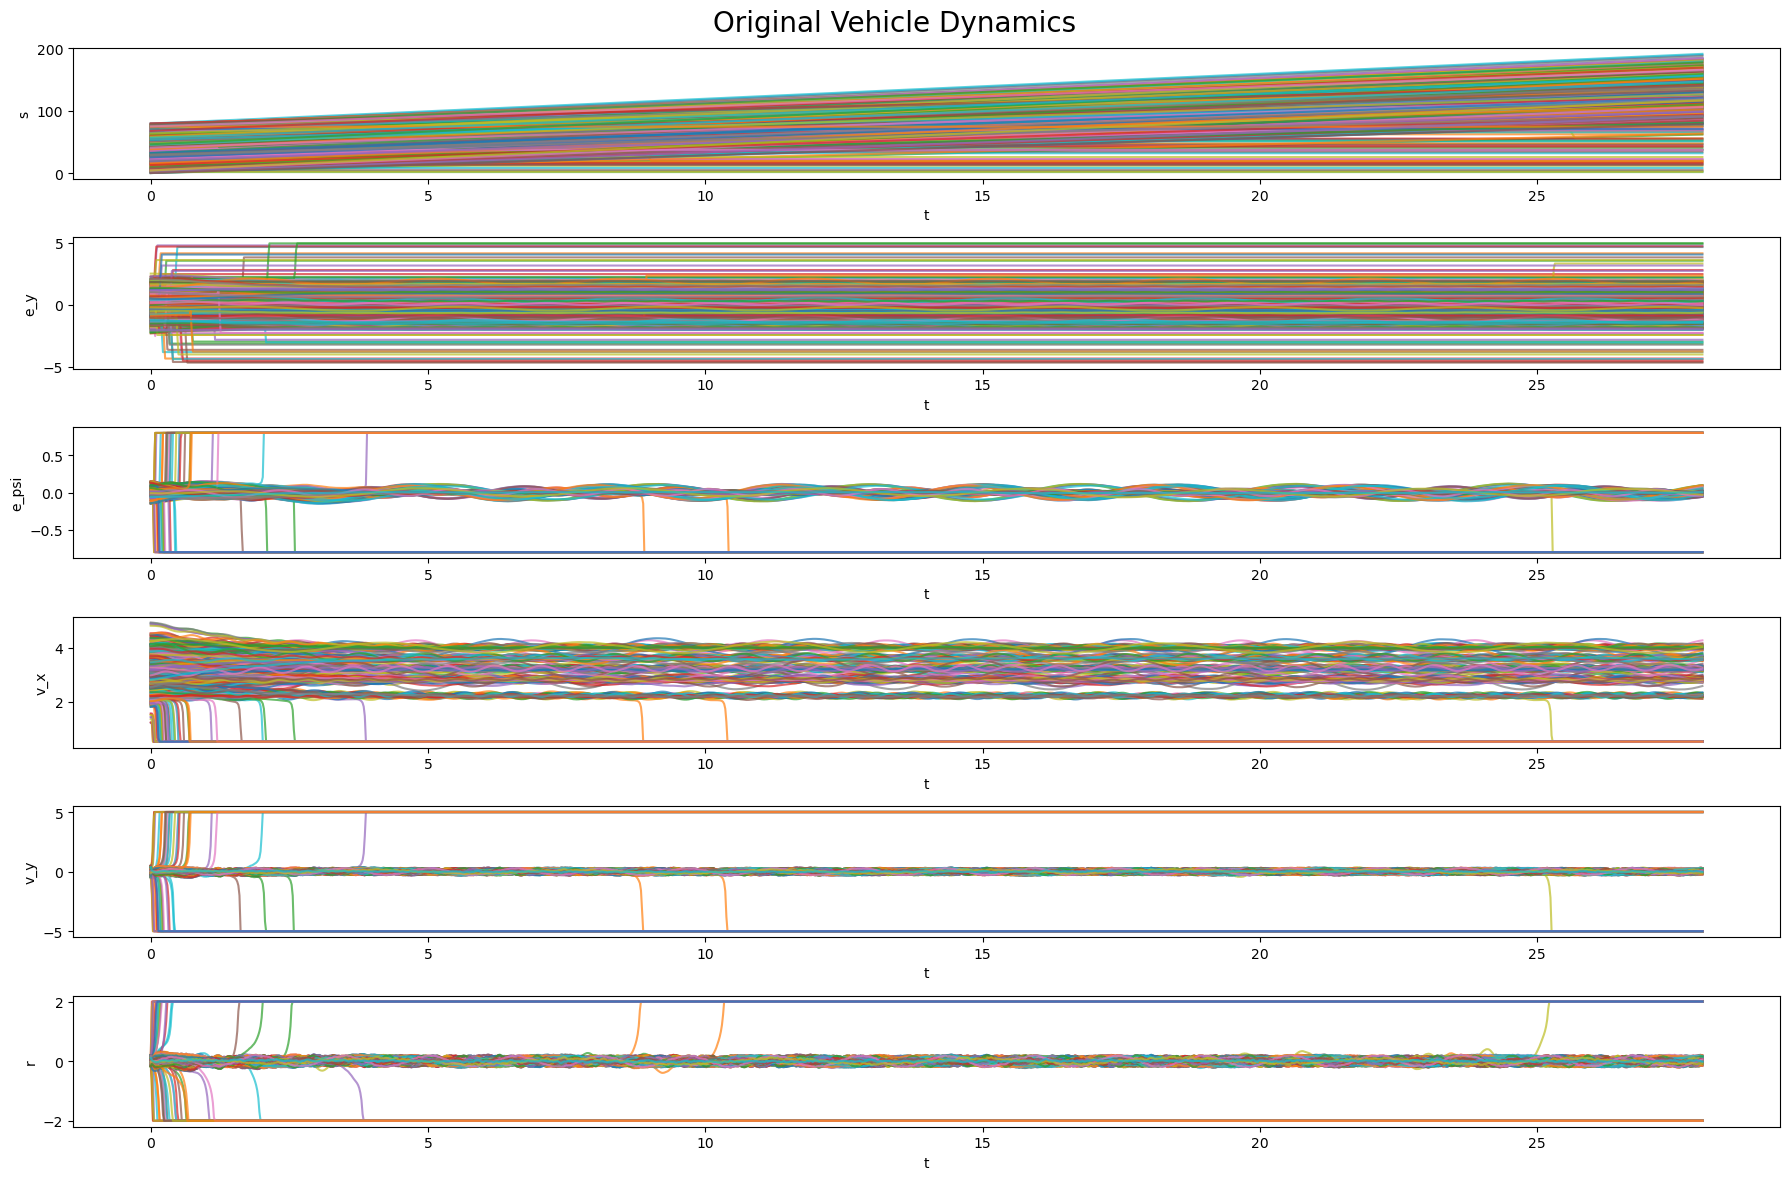

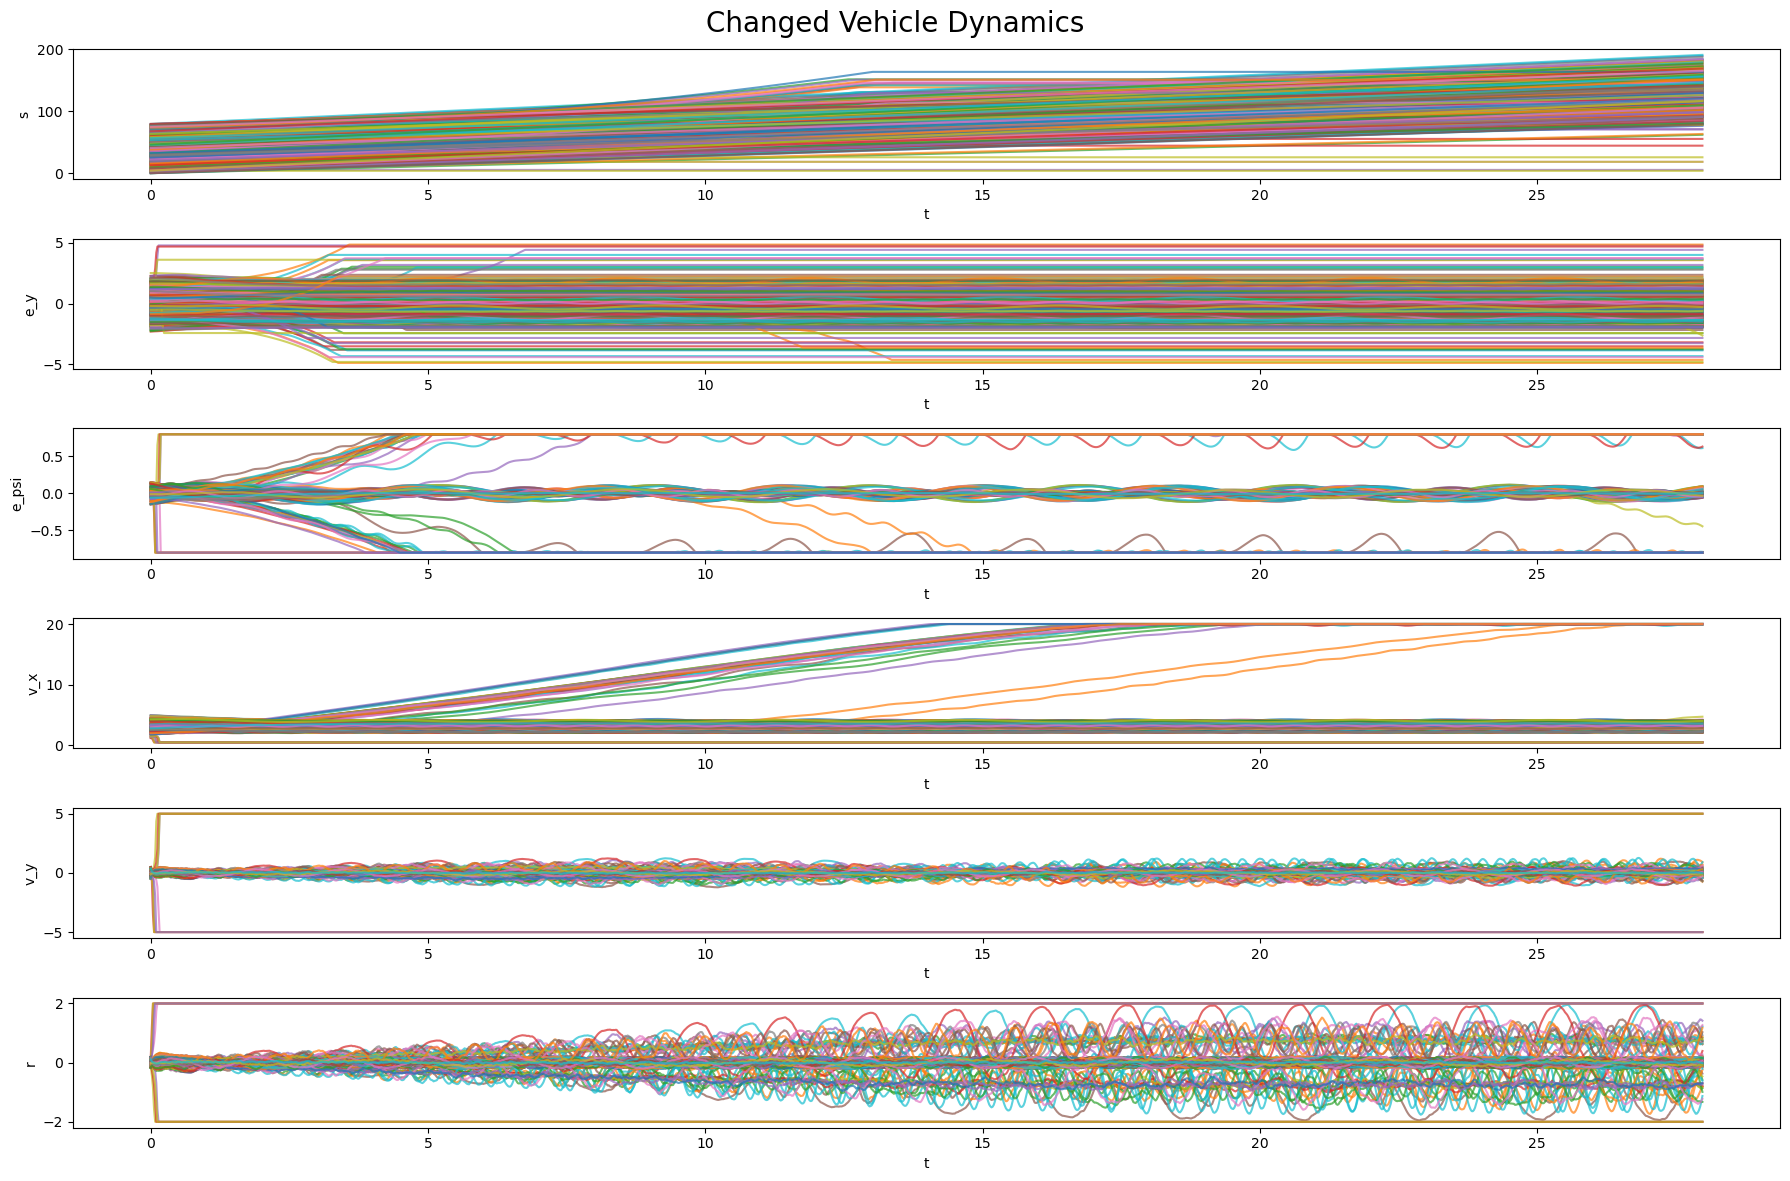

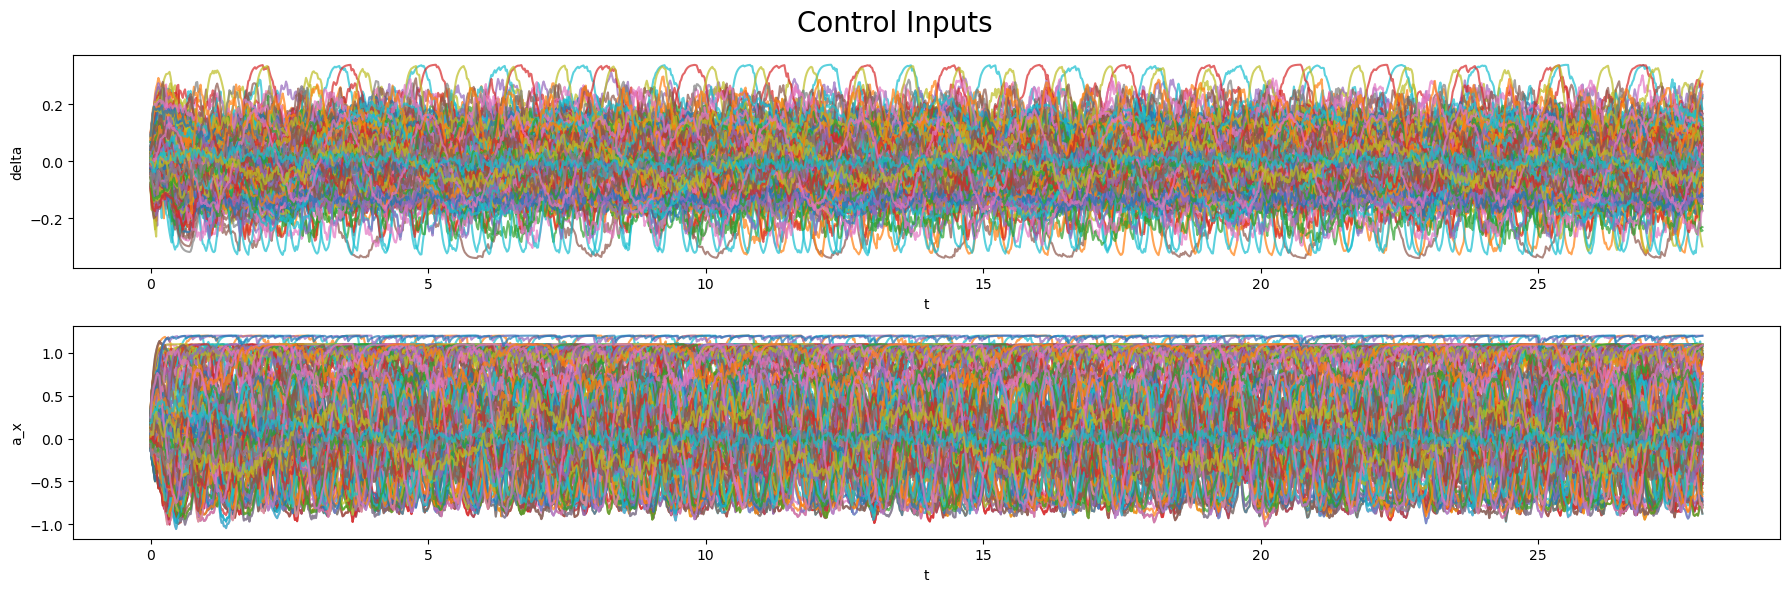

In [4]:

# =============================================================================
# 系统拟合
# =============================================================================
linear = True
set_global_seed(RUN_CFG["seed"], deterministic=KOOPMAN_CFG["deterministic_training"])

# =============================================================================
# 数据生成 (针对 60m 高曲率双移线优化：丰富场景 + 物理不变性数据增强)
# =============================================================================
sys_pars_base = {}

# 6 states: x=[s, e_y, e_psi, v_x, v_y, r]
num_states = 6
num_inputs = 2
dt = 0.02

sys_pars_base["num_states"] = num_states
sys_pars_base["num_inputs"] = num_inputs
sys_pars_base["dt"] = dt

# nominal vehicle parameters
sys_pars_base["m"] = 1500.0
sys_pars_base["Iz"] = 2250.0
sys_pars_base["lf"] = 1.2
sys_pars_base["lr"] = 1.6
sys_pars_base["Cf"] = 80000.0
sys_pars_base["Cr"] = 80000.0
sys_pars_base["curvature_ref"] = 0.0
sys_pars_base["uncertainty"] = "NA"
sys_pars_base["amp"] = 0.0

sys_pars_base["road_modes"] = ['dlc']
sys_pars_base["road_mode_probs"] = [1.0]

sys_pars_base["u_modes"] = ['feedback_dominant', 'sinusoidal', 'mixed']
sys_pars_base["u_mode_probs"] = [0.40, 0.30, 0.30]  # 稍微调整激励比例

sys_pars_base["alpha_u"] = 0.70
sys_pars_base["s_margin"] = 15.0
sys_pars_base["seed"] = RUN_CFG["seed"]

# changed vehicle parameters
sys_pars_new_base = dict(sys_pars_base)
sys_pars_new_base["m"] = 1650.0
sys_pars_new_base["Iz"] = 2400.0
sys_pars_new_base["Cf"] = 70000.0
sys_pars_new_base["Cr"] = 70000.0

# sys_pars_new_base = dict(sys_pars_base)

sensor_noise = False
SNR_DB = 30
train_path_length_target = 60.0
num_snaps = 1400

configs = [
    {"vx_ref": 2.2, "delta_max": 0.34, "ax_max": 1.10, "freq": 2.2},
    {"vx_ref": 2.8, "delta_max": 0.32, "ax_max": 1.20, "freq": 2.0},
    {"vx_ref": 3.2, "delta_max": 0.30, "ax_max": 1.20, "freq": 1.8},
    {"vx_ref": 3.6, "delta_max": 0.28, "ax_max": 1.10, "freq": 1.6},
    {"vx_ref": 4.0, "delta_max": 0.25, "ax_max": 1.00, "freq": 1.4},
]

num_traj_per_batch = 90
X_list, X_changed_list, U_list = [], [], []

print("正在生成覆盖60m高曲率双移线边界条件的多场景数据...")
for cfg in configs:
    sp = dict(sys_pars_base)
    sp.update(cfg)

    sp_new = dict(sys_pars_new_base)
    sp_new.update(cfg)

    X_b, X_changed_b, U_b = single_vehicle_data_gen_multi(
        num_traj_per_batch, num_snaps, sp, sp_new, sensor_noise, SNR_DB
    )
    X_list.append(X_b)
    X_changed_list.append(X_changed_b)
    U_list.append(U_b)

X = np.concatenate(X_list, axis=0)
X_changed = np.concatenate(X_changed_list, axis=0)
U = np.concatenate(U_list, axis=0)
num_traj = X.shape[0]  # Total 400

# 2. 【核心】数据增强 (Data Augmentation)
# 因为在直道上 (curvature_ref=0) 车辆的动态方程不受绝对纵向距离 s 和横向偏移 e_y 的影响
# 所以我们可以直接随机平移 s 和 e_y，扩大 Standardizer 的分布覆盖面，彻底解决饱和越界问题！
np.random.seed(RUN_CFG["seed"])
random.seed(RUN_CFG["seed"])
for i in range(num_traj):
    s_shift = np.random.uniform(0.0, 80.0)  # 覆盖 60m 高曲率轨迹并留冗余
    ey_shift = np.random.uniform(-2.0, 2.0)  # 覆盖 DLC 的侧向偏差并留出充足泛化裕度

    X[i, :, 0] += s_shift
    X_changed[i, :, 0] += s_shift
    X[i, :, 1] += ey_shift
    X_changed[i, :, 1] += ey_shift

# 打乱数据以防止验证集切分时分布不均
indices = np.random.permutation(num_traj)
X = X[indices]
X_changed = X_changed[indices]
U = U[indices]

num_train = int(0.8 * num_traj)
num_val = num_traj - num_train

sys_pars = dict(sys_pars_base)
sys_pars.update({"vx_ref": 3.0, "delta_max": 0.22, "ax_max": 1.0, "freq": 1.8})

sys_pars_new = dict(sys_pars_new_base)
sys_pars_new.update({"vx_ref": 3.0, "delta_max": 0.22, "ax_max": 1.0, "freq": 1.8})

print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)

os.makedirs("saved_data/single_vehicle", exist_ok=True)

dataset_tag = "60m_highcurv"
dataset_npz = f"saved_data/single_vehicle/offline_dataset_{dataset_tag}.npz"
dataset_pars = f"saved_data/single_vehicle/offline_dataset_pars_{dataset_tag}.pkl"

np.savez_compressed(
    dataset_npz,
    X=X,
    X_changed=X_changed,
    U=U
)

with open(dataset_pars, "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB,
        "dataset_tag": dataset_tag,
        "train_path_length_target": train_path_length_target
    }, f)

# 兼容旧流程：同时覆盖默认文件名
np.savez_compressed(
    "saved_data/single_vehicle/offline_dataset.npz",
    X=X,
    X_changed=X_changed,
    U=U
)
with open("saved_data/single_vehicle/offline_dataset_pars.pkl", "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB,
        "dataset_tag": dataset_tag,
        "train_path_length_target": train_path_length_target
    }, f)

print(f"离线数据已保存: {dataset_npz}")

state_labels = ["s", "e_y", "e_psi", "v_x", "v_y", "r"]
input_labels = ["delta", "a_x"]
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Original Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Changed Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
for j in range(num_traj):
    for i in range(num_inputs):
        plt.subplot(num_inputs, 1, i + 1)
        plt.plot(t_train[:-1], U[j, :, i], alpha=0.7)
        plt.ylabel(input_labels[i])
        plt.xlabel("t")
plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

Model save path: saved_models/single_vehicle/linear/Koop_vehicle_Dim20_dt_0.02.pth
历史模型读取失败，跳过历史平滑: <built-in method __setstate__ of torch._C.Generator object at 0x0000024D22A03A90> returned a result with an exception set
✅ U_curr 与 X_curr 样本数匹配: 503280
✅ U_curr 与 X_curr 样本数匹配: 125820
Epoch [  10/140] | Train  total=4.7143e-04  pred=2.8388e-04  lifted=7.1465e-05| Val    total=4.0405e-04  pred=2.5018e-04  lifted=6.0613e-05
Epoch [  20/140] | Train  total=2.8919e-04  pred=2.8335e-04  lifted=7.5746e-05| Val    total=2.5193e-04  pred=2.4761e-04  lifted=6.0851e-05
Epoch [  30/140] | Train  total=2.9258e-04  pred=2.8278e-04  lifted=1.5221e-04| Val    total=2.5617e-04  pred=2.4734e-04  lifted=1.1894e-04
Epoch [  40/140] | Train  total=2.8724e-04  pred=2.8096e-04  lifted=7.5745e-05| Val    total=2.5223e-04  pred=2.4721e-04  lifted=6.1512e-05
Epoch [  50/140] | Train  total=2.8705e-04  pred=2.8238e-04  lifted=7.6288e-05| Val    total=2.5122e-04  pred=2.4711e-04  lifted=5.9020e-05
Epoch [  60/14

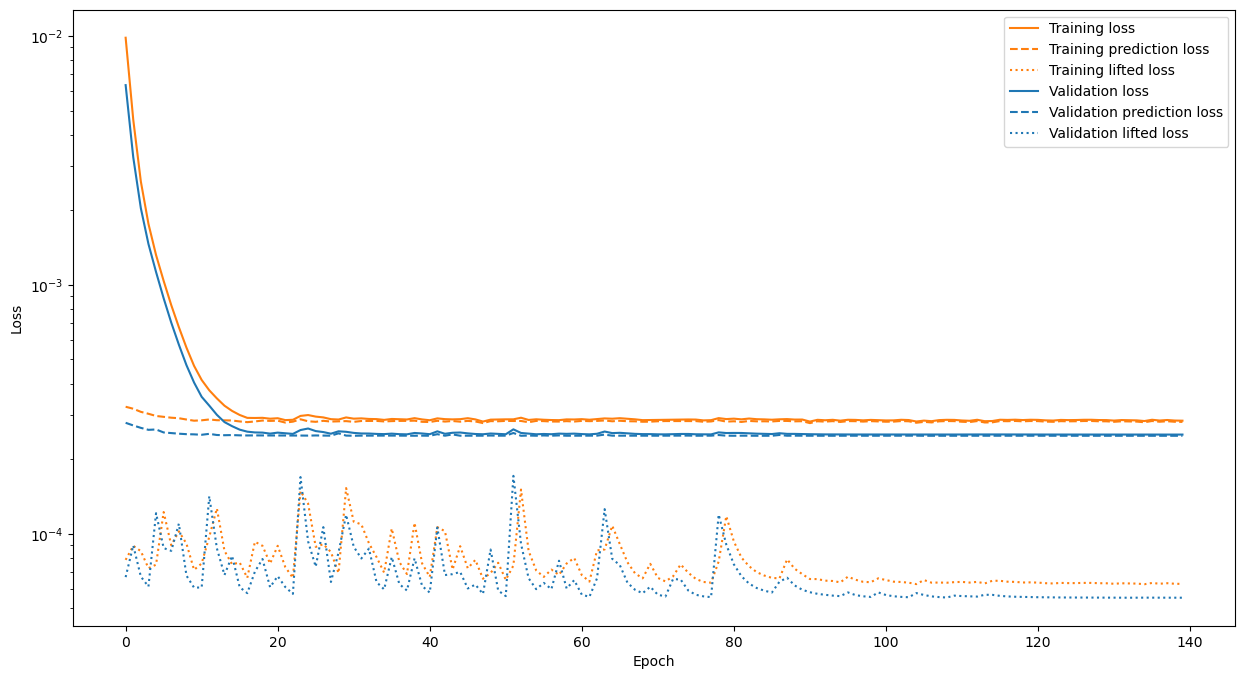

In [5]:
# =============================================================================
# Learning Koopman
# =============================================================================
xs_train, us_train = X[:num_train, :, :], U[:num_train, :, :]
xs_val, us_val = X[num_train:, :, :], U[num_train:, :, :]

net_params_lin = {}
net_params_lin["state_dim"] = num_states
net_params_lin["ctrl_dim"] = num_inputs
net_params_lin["encoder_hidden_width"] = KOOPMAN_CFG["encoder_hidden_width"]
net_params_lin["encoder_hidden_depth"] = KOOPMAN_CFG["encoder_hidden_depth"]
net_params_lin["encoder_output_dim"] = KOOPMAN_CFG["encoder_output_dim"]
net_params_lin["optimizer"] = "adam"
net_params_lin["activation_type"] = "tanh"
net_params_lin["lr"] = KOOPMAN_CFG["lr"]
net_params_lin["epochs"] = KOOPMAN_CFG["epochs"]
net_params_lin["batch_size"] = KOOPMAN_CFG["batch_size"]

net_params_lin["eig_loss"] = True
net_params_lin["eig_loss_coeff"] = 0.20
net_params_lin["lifted_loss_penalty"] = 0.05

net_params_lin["l2_reg"] = 1e-4
net_params_lin["l1_reg"] = 1e-7
net_params_lin["first_obs_const"] = True
net_params_lin["override_C"] = True
net_params_lin["dt"] = dt
net_params_lin["weight_decay"] = KOOPMAN_CFG["weight_decay"]

train = RUN_CFG["enable_koopman_training"]
standardize = True

os.makedirs("saved_models/single_vehicle/linear", exist_ok=True)

file_koop_linear = (
        "saved_models/single_vehicle/linear/"
        + "Koop_vehicle_Dim"
        + str(net_params_lin["encoder_output_dim"])
        + "_dt_"
        + str(dt)
        + ".pth"
)

print("Model save path:", file_koop_linear)

standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)

set_global_seed(RUN_CFG["seed"], deterministic=KOOPMAN_CFG["deterministic_training"])
torch.cuda.empty_cache()

prev_A = prev_B = None
if RUN_CFG["enable_koopman_linear_refit"] and os.path.exists(file_koop_linear):
    try:
        prev_model = torch.load(file_koop_linear, map_location=DEVICE, weights_only=False)
        if not hasattr(prev_model, "A_lin") or not hasattr(prev_model, "B_lin"):
            prev_model.construct_koopman_model()
        prev_A = np.array(prev_model.A_lin, dtype=np.float32)
        prev_B = np.array(prev_model.B_lin, dtype=np.float32)
        print("检测到历史模型，将用于平滑本次线性矩阵。")
    except Exception as e:
        print("历史模型读取失败，跳过历史平滑:", e)

if train:
    if standardize:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            standardizer_x=standardizer_x_kdnn,
            standardizer_u=standardizer_u_kdnn,
            device=DEVICE
        )
    else:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            device=DEVICE
        )

    model_koop_dnn_lin = KoopDNN_linear(net)

    # 强制对齐：x 和 u 的时间维以最小长度为准
    min_t_train = min(xs_train.shape[1], us_train.shape[1])
    xs_train = xs_train[:, :min_t_train, :]
    us_train = us_train[:, :min_t_train, :]

    min_t_val = min(xs_val.shape[1], us_val.shape[1])
    xs_val = xs_val[:, :min_t_val, :]
    us_val = us_val[:, :min_t_val, :]

    model_koop_dnn_lin.set_datasets(
        xs_train,
        u_train=us_train,
        x_val=xs_val,
        u_val=us_val
    )

    X_train, y_train = model_koop_dnn_lin.net.process(
        model_koop_dnn_lin.x_train, data_u=model_koop_dnn_lin.u_train
    )
    X_val, y_val = model_koop_dnn_lin.net.process(
        model_koop_dnn_lin.x_val, data_u=model_koop_dnn_lin.u_val, train_mode=False
    )

    from torch.utils.data import TensorDataset, DataLoader

    X_train_t = torch.from_numpy(X_train).float()
    y_train_t = torch.from_numpy(y_train).float()
    X_val_t = torch.from_numpy(X_val).float()
    y_val_t = torch.from_numpy(y_val).float()

    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)

    loader_generator = torch.Generator()
    loader_generator.manual_seed(RUN_CFG["seed"])

    train_loader = DataLoader(
        train_dataset,
        batch_size=net_params_lin["batch_size"],
        shuffle=True,
        num_workers=0,
        pin_memory=True,
        drop_last=True,
        persistent_workers=False,
        prefetch_factor=None,
        generator=loader_generator
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=net_params_lin["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    model_koop_dnn_lin.train_loader = train_loader
    model_koop_dnn_lin.val_loader = val_loader

    model_koop_dnn_lin.model_pipeline(net_params_lin, print_epoch=True)
else:
    model_koop_dnn_lin = torch.load(file_koop_linear, map_location=DEVICE, weights_only=False)
    model_koop_dnn_lin.net.to(DEVICE)
    model_koop_dnn_lin.net.device = DEVICE

# 始终构造一次线性 Koopman 矩阵（供 MPC 使用）
model_koop_dnn_lin.construct_koopman_model()

if RUN_CFG["enable_koopman_linear_refit"]:
    A_fit, B_fit, fit_info = fit_koopman_linear_matrices(
        model_koop_dnn_lin,
        xs_train,
        us_train,
        ridge_lambda=KOOPMAN_CFG["ridge_lambda"],
        batch_size=8192
    )

    A_refined = blend_matrix(model_koop_dnn_lin.A_lin.astype(np.float32), A_fit, KOOPMAN_CFG["linear_fit_blend"])
    B_refined = blend_matrix(model_koop_dnn_lin.B_lin.astype(np.float32), B_fit, KOOPMAN_CFG["linear_fit_blend"])

    if prev_A is not None and prev_B is not None:
        A_refined = blend_matrix(A_refined, prev_A, KOOPMAN_CFG["previous_model_blend"])
        B_refined = blend_matrix(B_refined, prev_B, KOOPMAN_CFG["previous_model_blend"])

    model_koop_dnn_lin.A_lin = A_refined
    model_koop_dnn_lin.B_lin = B_refined

    with torch.no_grad():
        model_koop_dnn_lin.net.A.weight.copy_(torch.from_numpy(A_refined).to(DEVICE))
        model_koop_dnn_lin.net.B.weight.copy_(torch.from_numpy(B_refined).to(DEVICE))

    print(f"线性重拟合完成: samples={fit_info['samples']}, lifted_rmse={fit_info['lifted_rmse']:.4e}")

if train:
    torch.save(model_koop_dnn_lin, file_koop_linear)

if len(model_koop_dnn_lin.train_loss_hist) > 0 and len(model_koop_dnn_lin.val_loss_hist) > 0:
    train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
    train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
    train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
    val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
    val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
    val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
    epochs = np.arange(0, len(train_loss))

    plt.figure(figsize=(15, 8))
    plt.plot(epochs, train_loss, color="tab:orange", label="Training loss")
    plt.plot(epochs, train_pred_loss, "--", color="tab:orange", label="Training prediction loss")
    plt.plot(epochs, train_lifted_loss, ":", color="tab:orange", label="Training lifted loss")
    plt.plot(epochs, val_loss, color="tab:blue", label="Validation loss")
    plt.plot(epochs, val_pred_loss, "--", color="tab:blue", label="Validation prediction loss")
    plt.plot(epochs, val_lifted_loss, ":", color="tab:blue", label="Validation lifted loss")
    plt.legend()
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.yscale("log")
    plt.show()
else:
    print("未执行本轮训练，跳过训练曲线绘制。")


A, B, C shapes: (27, 27) (27, 2) (6, 27)
stable spectral radius = 0.99900013
A, B, C shapes: (27, 27) (27, 2) (6, 27)
spectral radius = 1.0040355
eigvals = [0.87563884+0.0405745j  0.87563884-0.0405745j  1.0040355 +0.j
 0.99997896+0.00026091j 0.99997896-0.00026091j 1.0002073 +0.j
 1.0011586 +0.j         0.38890952+0.02725976j 0.38890952-0.02725976j
 0.38439244+0.02260367j 0.38439244-0.02260367j 0.3897486 +0.02169115j
 0.3897486 -0.02169115j 0.391304  +0.01429176j 0.391304  -0.01429176j
 0.38267824+0.01334494j 0.38267824-0.01334494j 0.39325574+0.00536682j
 0.39325574-0.00536682j 0.38052136+0.00550874j 0.38052136-0.00550874j
 0.38476565+0.00613505j 0.38476565-0.00613505j 0.38595465+0.00308962j
 0.38595465-0.00308962j 0.386502  +0.00072935j 0.386502  -0.00072935j]


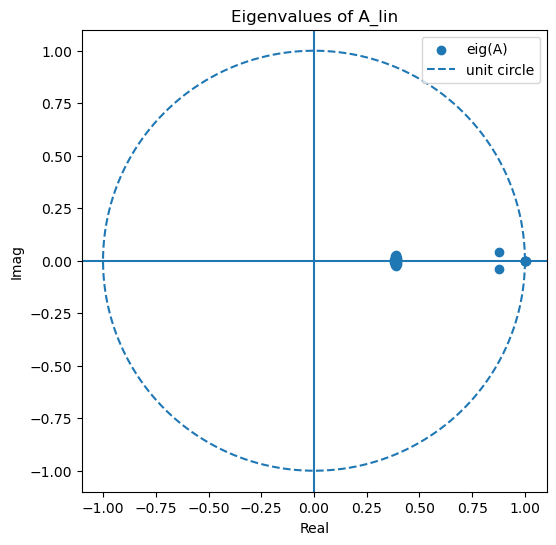

✅ U_curr 与 X_curr 样本数匹配: 99
✅ U_curr 与 X_curr 样本数匹配: 99
x_unchanged_scaled shape: (99, 6)
u_scaled shape: (99, 2)
x_changed_scaled shape: (99, 6)
x_changed_prime_scaled shape: (99, 0)


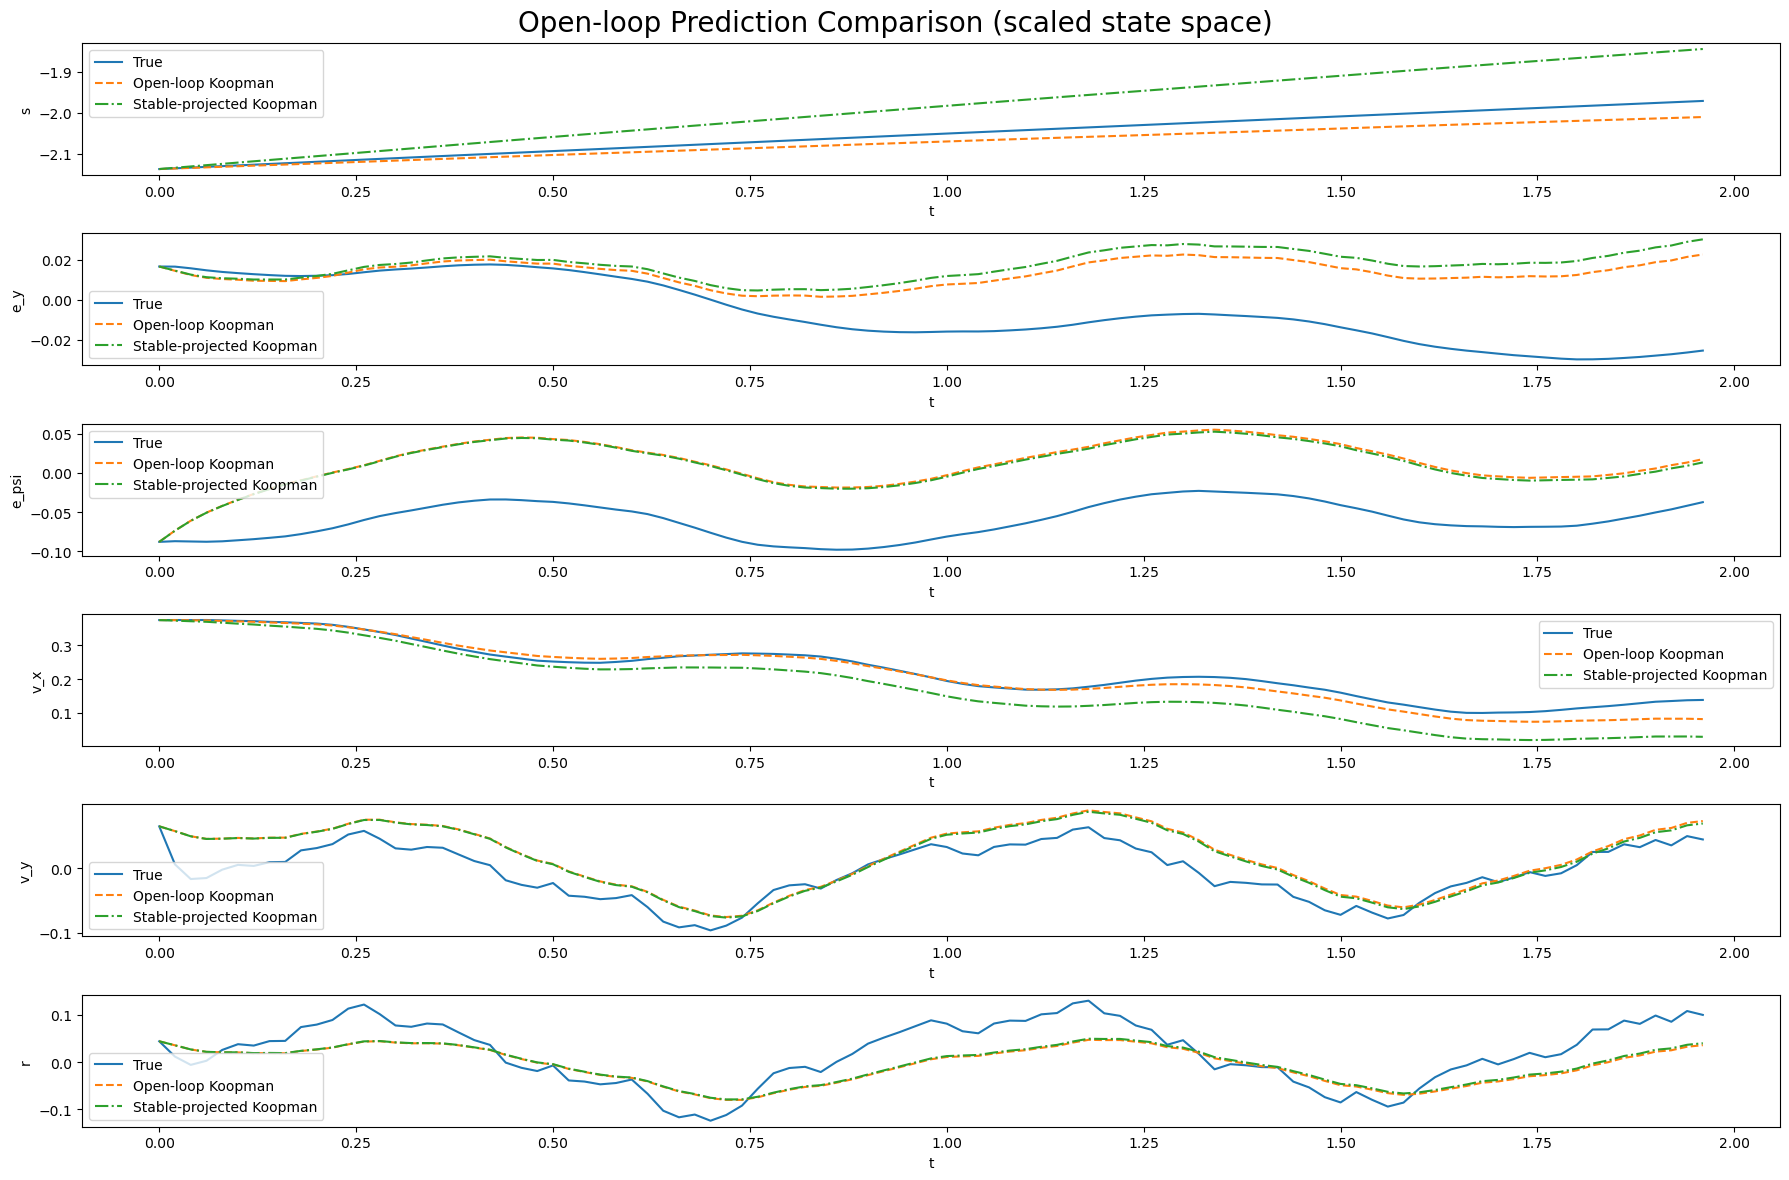

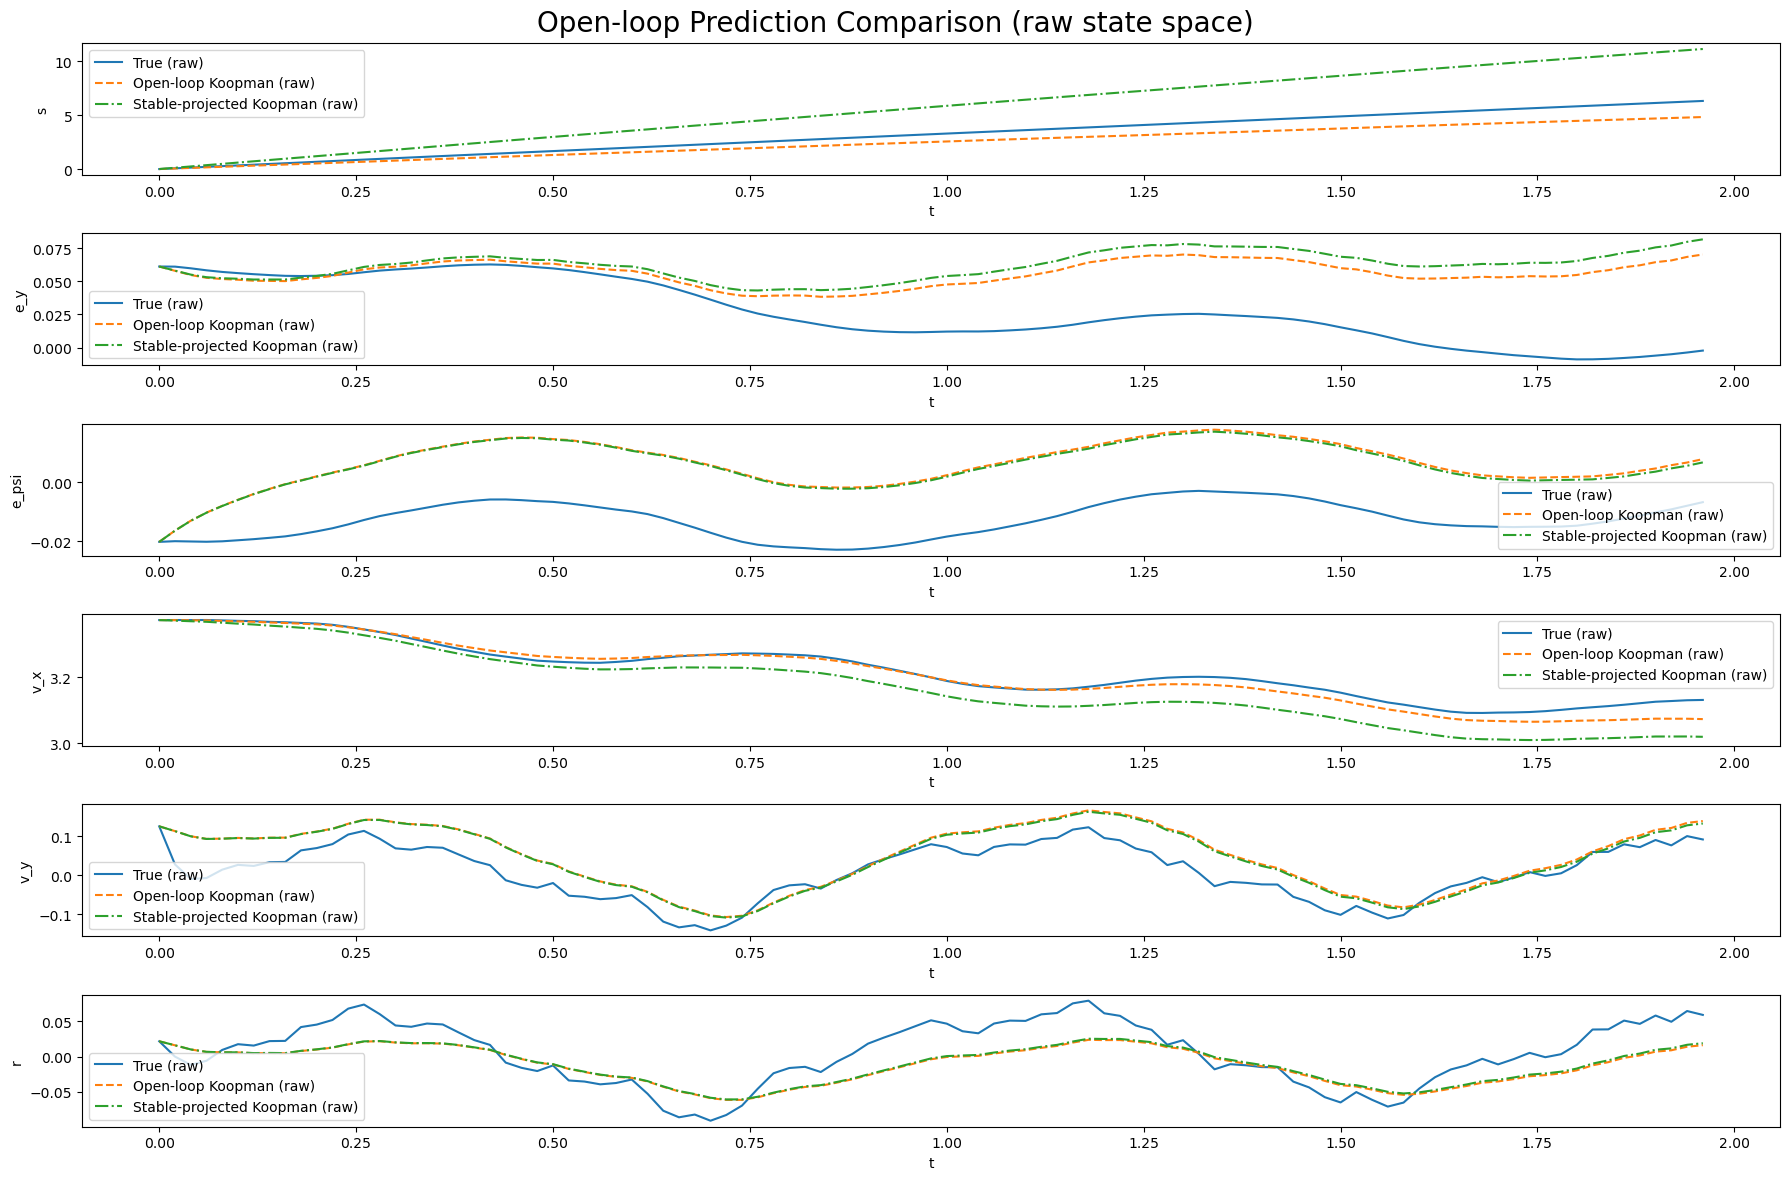

In [6]:

# =============================================================================
# Koopman Model Parameters (Open Loop Test)
# =============================================================================
num_snaps_test = 100
T_test = np.linspace(0, (num_snaps_test - 1) * dt, num_snaps_test)

num_traj_test = 1
first_obs_const = int(net_params_lin["first_obs_const"])
override_C = net_params_lin["override_C"]
if override_C:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + first_obs_const

x_unchanged_test, x_changed_test, u_test = single_vehicle_data_gen_multi(
    num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)

# ====================== 正确提取 Koopman 矩阵 ======================
# ====================== 正确提取 Koopman 矩阵 ======================
if not hasattr(model_koop_dnn_lin, 'A_lin'):
    print("⚠️ 尚未调用 construct_koopman_model()，现在自动调用...")
    model_koop_dnn_lin.construct_koopman_model()

A_lin = model_koop_dnn_lin.A_lin
B_lin = model_koop_dnn_lin.B_lin
C_lin = model_koop_dnn_lin.C_np

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([
    ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999
    for ev in eigvals
])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals = np.linalg.eigvals(A_lin)
spectral_radius = np.max(np.abs(eigvals))

print("spectral radius =", spectral_radius)
print("eigvals =", eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), label="eig(A)")
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), "--", label="unit circle")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.legend()
plt.title("Eigenvalues of A_lin")
plt.axis("equal")
plt.show()

X_unchanged_scaled, _ = model_koop_dnn_lin.net.process(x_unchanged_test, data_u=u_test)
X_changed_scaled, _ = model_koop_dnn_lin.net.process(x_changed_test, data_u=u_test)

x_unchanged_scaled = X_unchanged_scaled[:, :num_states]
u_scaled = X_unchanged_scaled[:, num_states:num_states + num_inputs]
x_unchanged_prime_scaled = X_unchanged_scaled[:, num_states + num_inputs:]

x_changed_scaled = X_changed_scaled[:, :num_states]
x_changed_prime_scaled = X_changed_scaled[:, num_states + num_inputs:]

print("x_unchanged_scaled shape:", x_unchanged_scaled.shape)
print("u_scaled shape:", u_scaled.shape)
print("x_changed_scaled shape:", x_changed_scaled.shape)
print("x_changed_prime_scaled shape:", x_changed_prime_scaled.shape)

num_pred = x_unchanged_scaled.shape[0]

z_lin = np.zeros((num_pred, n_obs_lin))
x_est_lin = np.zeros((num_pred, num_states))

z_lin[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)

x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin[k + 1, :] = np.matmul(z_lin[k, :], A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin[k + 1, :] = np.matmul(z_lin[k + 1, :], C_lin.T)

z_lin_stable = np.zeros((num_pred, n_obs_lin))
x_est_lin_stable = np.zeros((num_pred, num_states))

z_lin_stable[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin_stable[0, :] = np.matmul(z_lin_stable[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k, :], A_lin_stable.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k + 1, :], C_lin.T)

T_plot = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_unchanged_scaled[:, i], label="True")
    plt.plot(T_plot, x_est_lin[:, i], "--", label="Open-loop Koopman")
    plt.plot(T_plot, x_est_lin_stable[:, i], "-.", label="Stable-projected Koopman")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_est_lin_raw = standardizer_x_kdnn.inverse_transform(x_est_lin)
x_est_lin_stable_raw = standardizer_x_kdnn.inverse_transform(x_est_lin_stable)
x_true_raw = x_unchanged_test[0, :-1, :]

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_true_raw[:, i], label="True (raw)")
    plt.plot(T_plot, x_est_lin_raw[:, i], "--", label="Open-loop Koopman (raw)")
    plt.plot(T_plot, x_est_lin_stable_raw[:, i], "-.", label="Stable-projected Koopman (raw)")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

进行 one-step 预测 | 样本数: 99 | 状态维: 6


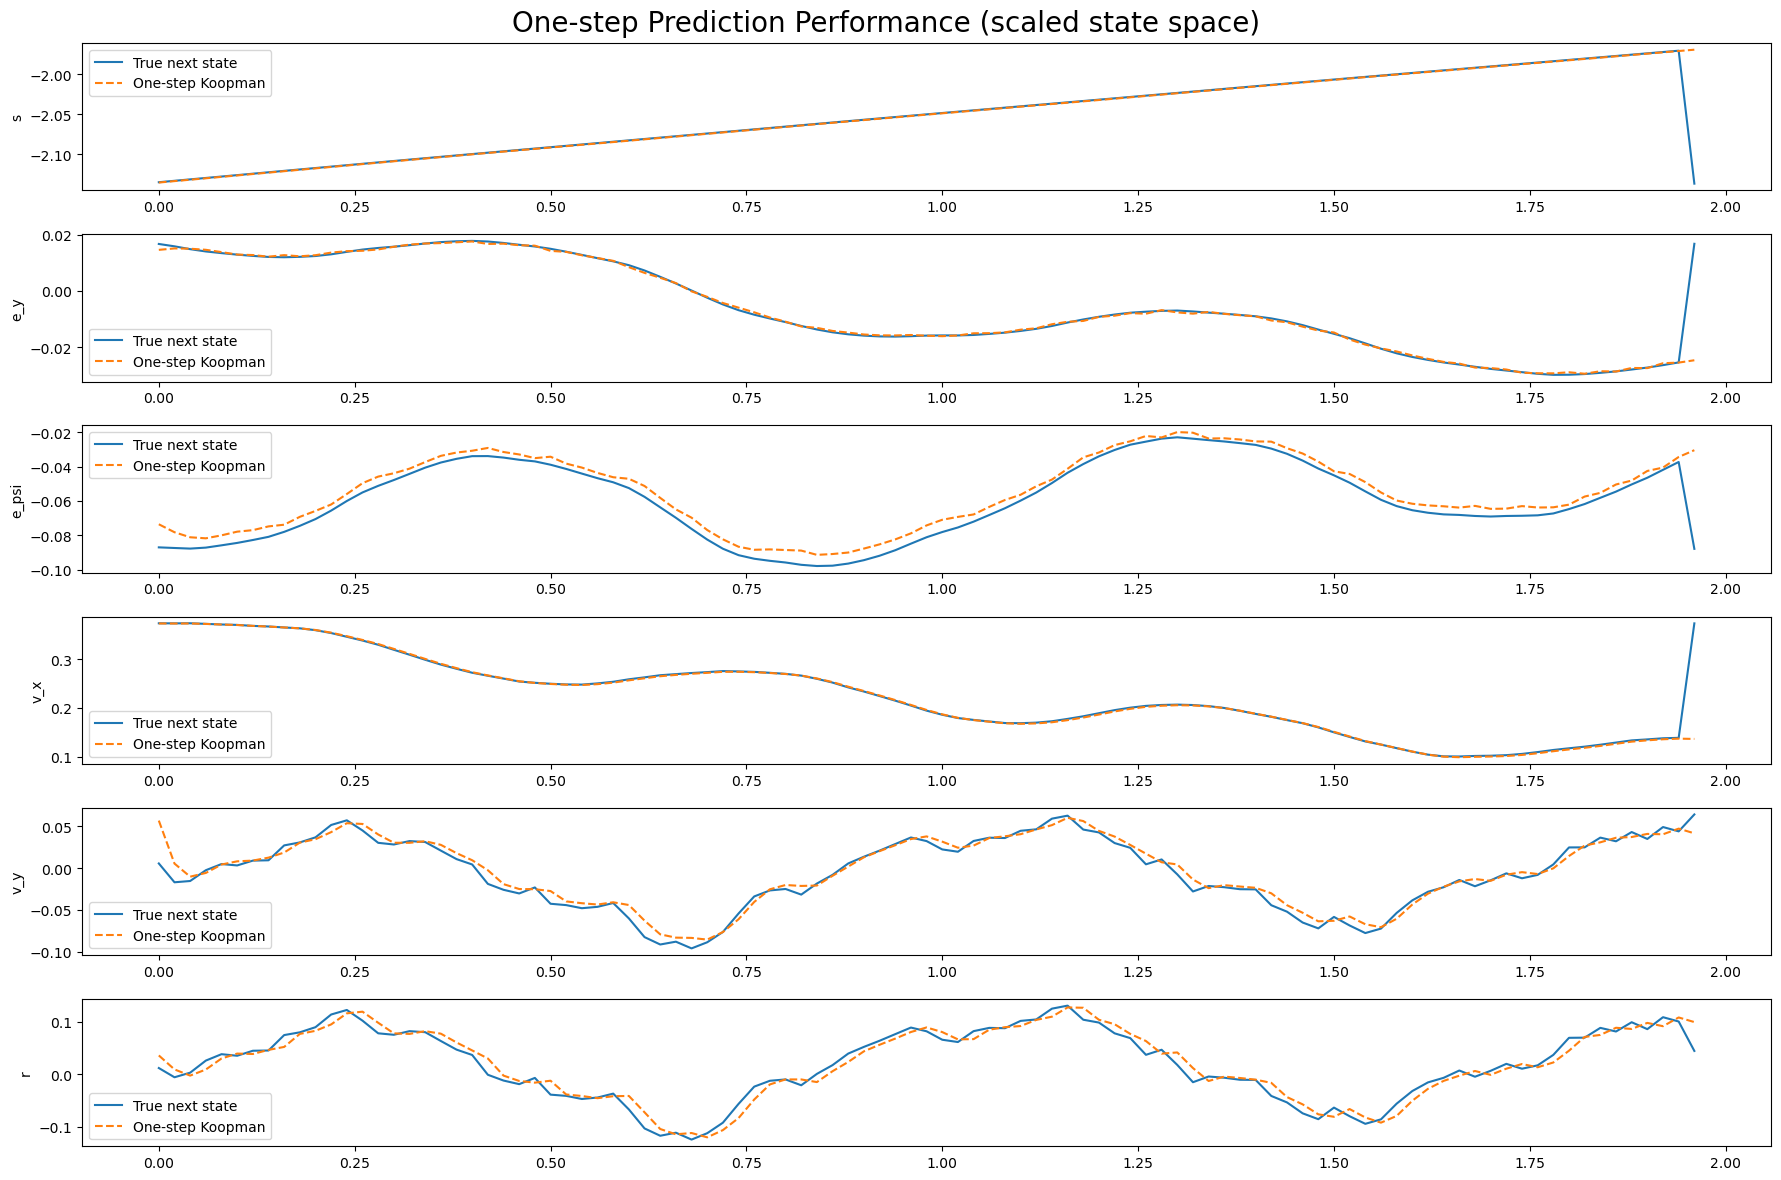

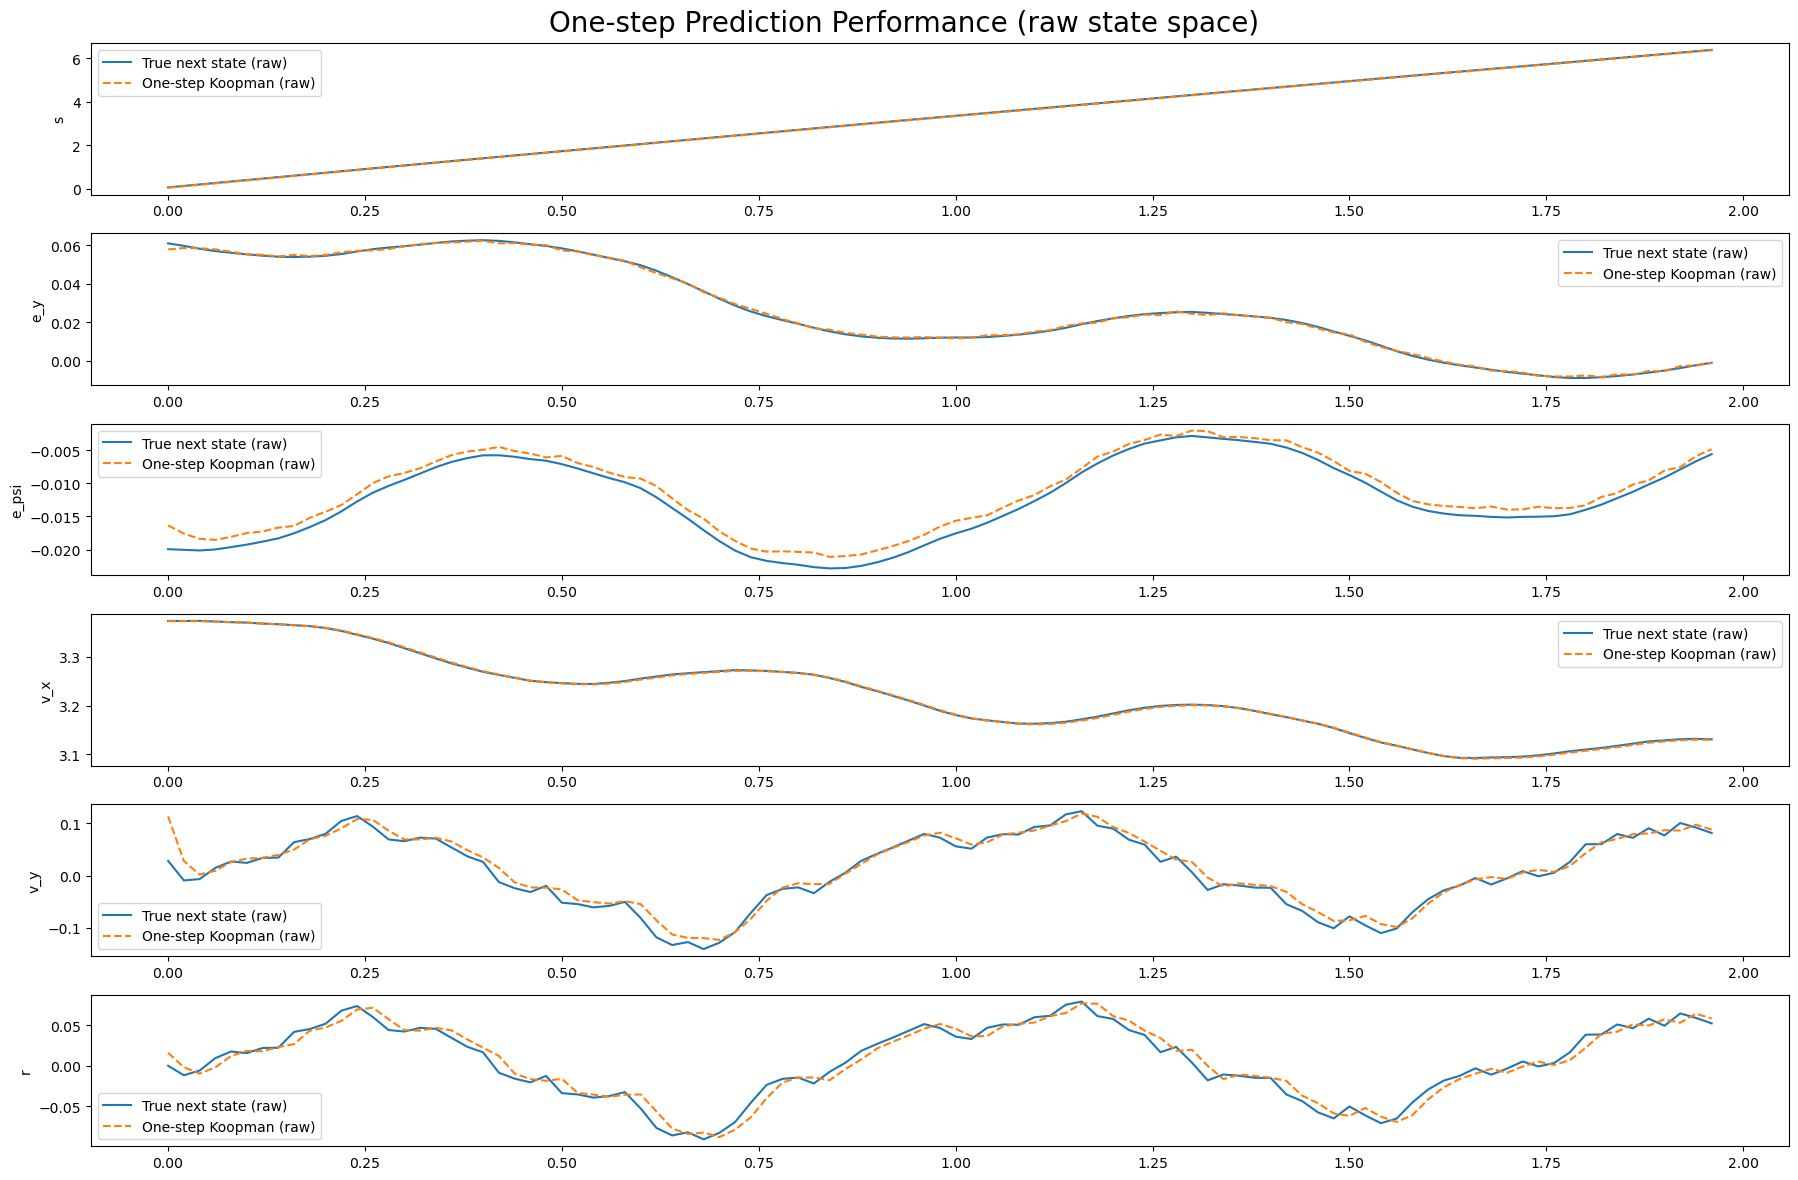

In [7]:

# ====================== One-step Prediction (修复空数组问题) ======================
# 正确计算有效样本数（process 已经切掉了最后一步）
num_pred = x_unchanged_scaled.shape[0]  # 应该等于 99

# 正确初始化（使用 num_pred 而不是像 x_unchanged_prime_scaled 这样可能为空的变量）
x_one_step_pred = np.zeros((num_pred, num_states))

print(f"进行 one-step 预测 | 样本数: {num_pred} | 状态维: {num_states}")

for k in range(num_pred):
    z_k = lift_scaled(x_unchanged_scaled[k, :], model_koop_dnn_lin, net_params_lin)
    z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)

T_plot_1 = np.arange(num_pred) * dt

# ====================== 绘图（scaled） ======================
plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)

    # 更符合逻辑的替代写法
    true_next = x_unchanged_prime_scaled[:num_pred, i] if x_unchanged_prime_scaled.shape[1] > 0 else np.roll(
        x_unchanged_scaled[:, i], -1)
    plt.plot(T_plot_1, true_next, label="True next state")

    plt.plot(T_plot_1, x_one_step_pred[:, i], "--", label="One-step Koopman")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

# ====================== 绘图（raw） ======================
x_one_step_pred_raw = standardizer_x_kdnn.inverse_transform(x_one_step_pred)

# True next state（注意对齐）
x_true_next_raw = x_unchanged_test[0, 1:1 + num_pred, :]

T_plot_raw = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_raw, x_true_next_raw[:, i], label="True next state (raw)")
    plt.plot(T_plot_raw, x_one_step_pred_raw[:, i], "--", label="One-step Koopman (raw)")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

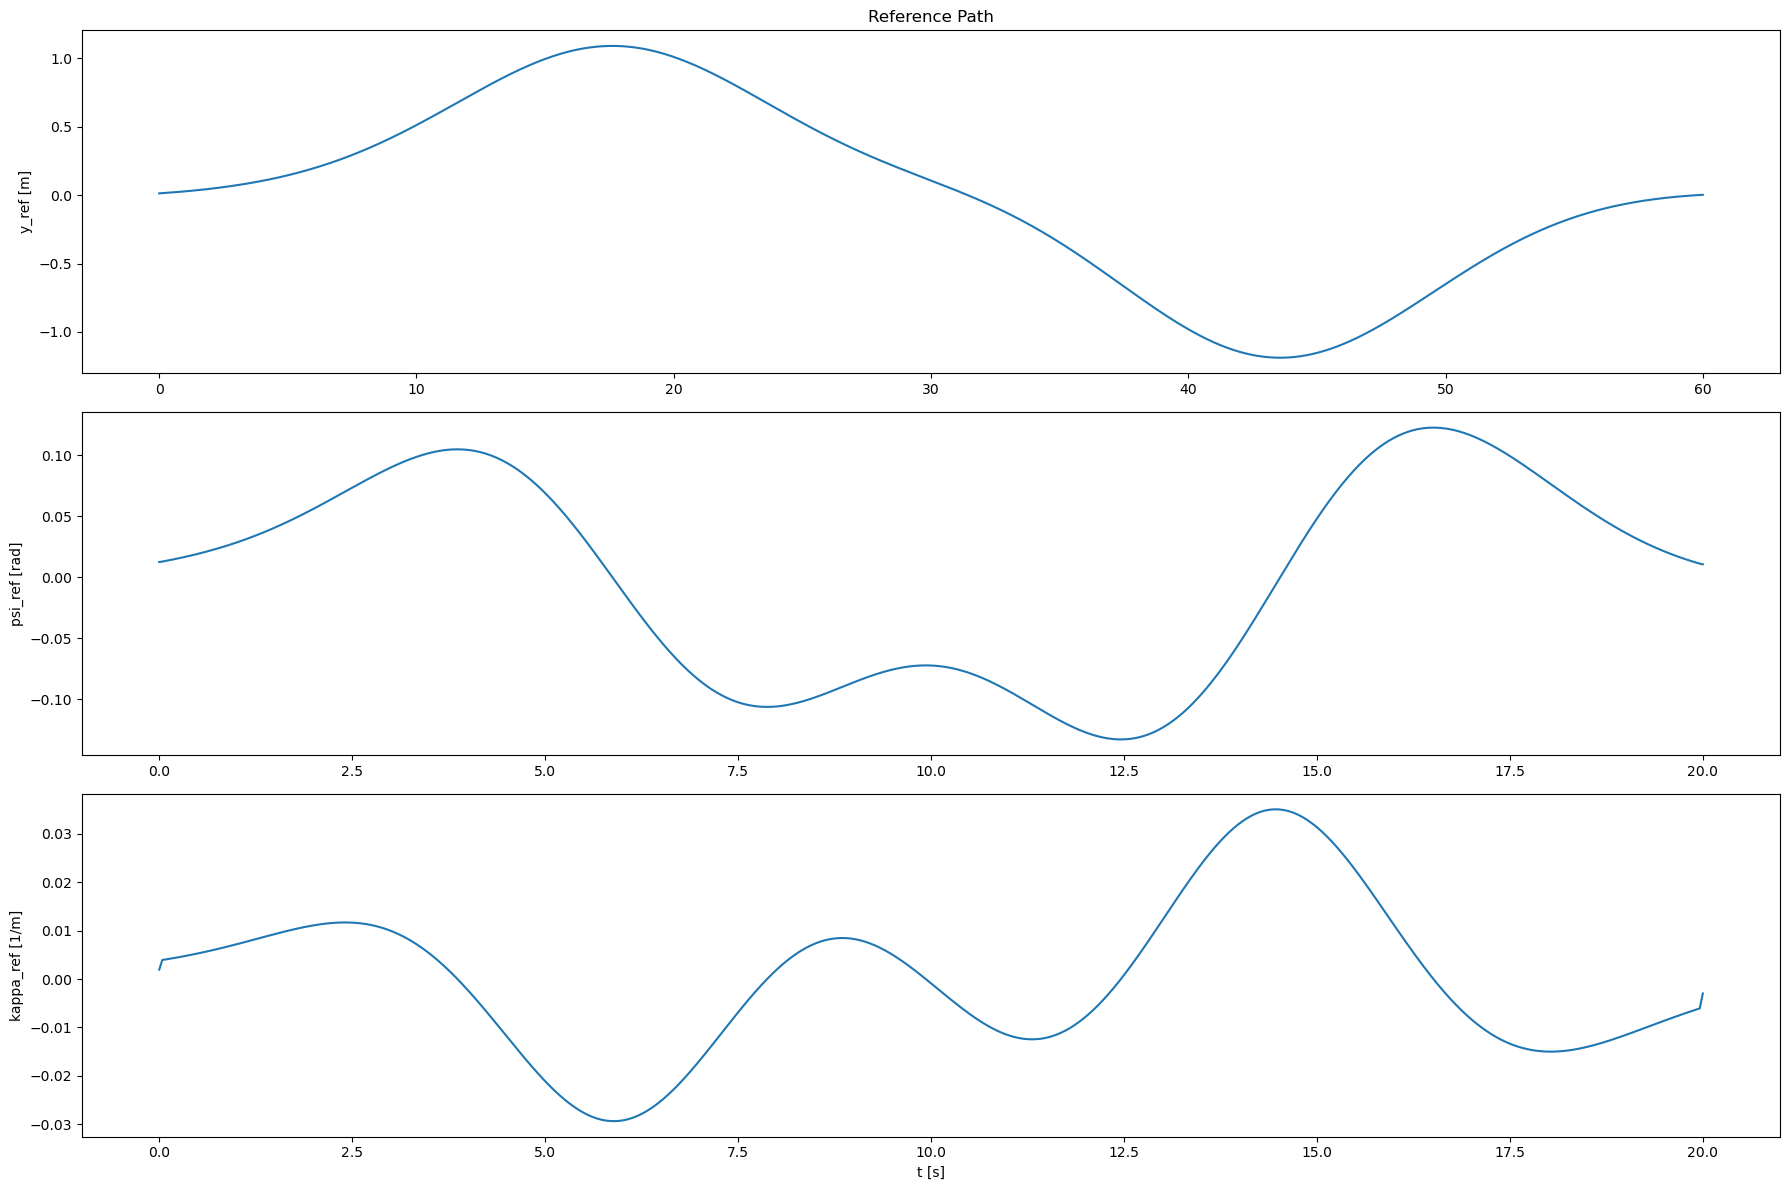

In [8]:
#
#=============================================================================
# Testing - 60m High-Curvature Double Lane Change Baseline
# =============================================================================

# =========================
# 四车参数统一定义（可开关）
# =========================
d_spacing = 5.0
num_vehicles = 4 if RUN_CFG["enable_four_vehicle"] else 1
vx_nom = 3.0

formation_offsets = [
    (0.0, 0.20),
    (0.0, -0.20),
    (-d_spacing, 0.20),
    (-d_spacing, -0.20),
]

x0_vehicles = []
for idx in range(num_vehicles):
    ds, dey = formation_offsets[idx]
    x0_vehicles.append(np.array([ds, dey, 0.0, vx_nom, 0.0, 0.0]))

# =========================
# Reference path generation
# =========================
path_length = MPC_CFG["path_length"]
T_traj = path_length / vx_nom
t_ref = np.arange(0, T_traj + dt, dt)
traj_length = t_ref.size
x_path = vx_nom * t_ref

if RUN_CFG["enable_curved_tracking"]:
    # 60m 工况下进一步增大曲率：更大幅值 + 更窄过渡 + 更强局部波动
    A1 = 1.15
    A2 = -1.15
    x1 = 0.30 * path_length
    x2 = 0.72 * path_length
    sigma1 = 0.10 * path_length
    sigma2 = 0.10 * path_length

    y_ref_dlc = (
        A1 * np.exp(-0.5 * ((x_path - x1) / sigma1) ** 2)
        + A2 * np.exp(-0.5 * ((x_path - x2) / sigma2) ** 2)
    )

    y_ref_wave = 0.09 * np.sin(2.0 * np.pi * 2.2 * x_path / path_length) * np.exp(
        -((x_path - 0.5 * path_length) / (0.45 * path_length)) ** 2
    )

    y_ref_path = y_ref_dlc + y_ref_wave
else:
    y_ref_path = np.zeros_like(x_path)

s_ref_path, psi_ref_path, curvature_ref_path = build_test_frenet_path_from_xy(
    x_path, y_ref_path
)

x_ref_raw = np.zeros((num_states, traj_length))
x_ref_raw[0, :] = s_ref_path
x_ref_raw[1, :] = 0.0
x_ref_raw[2, :] = 0.0
x_ref_raw[3, :] = vx_nom
x_ref_raw[4, :] = 0.0
x_ref_raw[5, :] = vx_nom * curvature_ref_path

x_ref_scaled = standardizer_x_kdnn.transform(x_ref_raw.T).T

plt.figure(figsize=(18, 12))
plt.subplot(3, 1, 1)
plt.plot(x_path, y_ref_path)
plt.ylabel("y_ref [m]")
plt.title("Reference Path")

plt.subplot(3, 1, 2)
plt.plot(t_ref, psi_ref_path)
plt.ylabel("psi_ref [rad]")

plt.subplot(3, 1, 3)
plt.plot(t_ref, curvature_ref_path)
plt.ylabel("kappa_ref [1/m]")
plt.xlabel("t [s]")
plt.tight_layout()
plt.show()


In [9]:
# =========================
# Solver settings（防卡死调优 + 可开关）
# =========================
solver_settings = {}
solver_settings["gen_embedded_ctrl"] = False
solver_settings["warm_start"] = True
solver_settings["polish"] = True
solver_settings["polish_refine_iter"] = 3
solver_settings["scaling"] = True
solver_settings["adaptive_rho"] = True
solver_settings["check_termination"] = 10
solver_settings["max_iter"] = 6000
solver_settings["eps_abs"] = 8e-4
solver_settings["eps_rel"] = 8e-4
solver_settings["eps_prim_inf"] = 1e-3
solver_settings["eps_dual_inf"] = 1e-3
solver_settings["sqp_step_size"] = 0.85
solver_settings["du_clip"] = 0.45
solver_settings["retry_on_fail"] = 1
solver_settings["retry_relax_factor"] = 1.8
solver_settings["accept_solved_inaccurate"] = True
solver_settings["accept_partial_solution"] = True
solver_settings["accept_partial_prim_res"] = 4e-3
solver_settings["accept_partial_dual_res"] = 4e-3
solver_settings["verbose"] = False

if RUN_CFG["enable_solver_guard"]:
    solver_settings["time_limit"] = MPC_CFG["osqp_time_limit"]

# 初始化参考轨迹列表
x_ref_mpc_vehicles = []


In [10]:
# =========================
# MPC horizon / ref preview + 对比试验建模准备
# =========================
N_lin_noadapt = MPC_CFG["horizon"]
max_iter_lin = MPC_CFG["max_sqp_iters"]

x_ref_mpc_vehicles = []
for v in range(num_vehicles):
    x_ref_raw_v = x_ref_raw.copy()
    x_ref_raw_v[0, :] += x0_vehicles[v][0]
    x_ref_raw_v[1, :] = x0_vehicles[v][1]
    x_ref_raw_v[2, :] = 0.0
    x_ref_raw_v[3, :] = vx_nom
    x_ref_raw_v[4:, :] = 0.0

    x_ref_scaled_v = standardizer_x_kdnn.transform(x_ref_raw_v.T).T
    x_ref_mpc_v = np.hstack((
        x_ref_scaled_v,
        np.tile(x_ref_scaled_v[:, -1].reshape(-1, 1), N_lin_noadapt + 2)
    ))
    x_ref_mpc_vehicles.append(x_ref_mpc_v)

# =========================
# Relaxed raw bounds -> scaled bounds
# =========================
xmin_raw = np.array([-10.0, -5.0, -1.2, 0.5, -4.0, -3.0])
xmax_raw = np.array([500.0, 5.0, 1.2, 8.0, 4.0, 3.0])

xmin_lin_noadapt = standardizer_x_kdnn.transform(xmin_raw.reshape(1, -1)).flatten()
xmax_lin_noadapt = standardizer_x_kdnn.transform(xmax_raw.reshape(1, -1)).flatten()

umax_lin_noadapt = np.array([0.08, 1.0])
umin_lin_noadapt = -umax_lin_noadapt

# ====================== 基础权重 ======================
Q_base_lin = scipy.sparse.diags([
    0.0,
    3500.0,
    1200.0,
    8.0,
    1.0,
    1.0
])

QN_base_lin = scipy.sparse.diags([
    0.0,
    5000.0,
    2000.0,
    12.0,
    1.0,
    1.0
])

R_mpc_lin_noadapt = scipy.sparse.diags([120.0, 12.0])


def spectral_project_matrix(A, radius=0.999):
    eigvals, eigvecs = np.linalg.eig(A)
    eigvals_proj = np.array([
        ev if np.abs(ev) <= radius else ev / np.abs(ev) * radius
        for ev in eigvals
    ])
    A_proj = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
    return np.real(A_proj)


def fit_raw_linear_model_scaled(xs_data, us_data, ridge_lambda=1e-4):
    t_eff = min(xs_data.shape[1] - 1, us_data.shape[1])

    x_k = xs_data[:, :t_eff, :].reshape(-1, num_states)
    x_k1 = xs_data[:, 1:t_eff + 1, :].reshape(-1, num_states)
    u_k = us_data[:, :t_eff, :].reshape(-1, num_inputs)

    x_k_s = standardizer_x_kdnn.transform(x_k)
    x_k1_s = standardizer_x_kdnn.transform(x_k1)
    u_k_s = standardizer_u_kdnn.transform(u_k)

    phi = np.hstack([x_k_s, u_k_s]).astype(np.float64)
    y = x_k1_s.astype(np.float64)

    eye = np.eye(phi.shape[1], dtype=np.float64)
    theta = np.linalg.solve(phi.T @ phi + ridge_lambda * eye, phi.T @ y)

    A_raw = theta[:num_states, :].T
    B_raw = theta[num_states:, :].T
    return A_raw.astype(np.float32), B_raw.astype(np.float32)


# 无 Koopman 对照模型（直接在 scaled 原状态空间拟合线性模型）
A_raw_scaled, B_raw_scaled = fit_raw_linear_model_scaled(xs_train, us_train, ridge_lambda=8e-5)
A_raw_scaled_stable = spectral_project_matrix(A_raw_scaled, radius=0.998)
C_raw_scaled = np.eye(num_states)

print("[对照模型] A_raw_scaled shape:", A_raw_scaled.shape, "| B_raw_scaled shape:", B_raw_scaled.shape)
print("[对照模型] spectral radius (stable proj):", np.max(np.abs(np.linalg.eigvals(A_raw_scaled_stable))))


[对照模型] A_raw_scaled shape: (6, 6) | B_raw_scaled shape: (6, 2)
[对照模型] spectral radius (stable proj): 0.9980001


In [11]:
# =========================
# 对比实验定义 + 通用仿真函数
# =========================
COMPARE_CFG = {
    # 快速对比模式：默认关闭，确保四方法×四车运行完整路径
    "quick_mode": False,
    "quick_steps": 99999,
    "horizon": 30,
    "max_sqp_iters": 2,
    "base_time_limit": 0.05,
    "log_interval": 100,
    # 完整路径保障：若名义步长内未到终点，允许继续跑 extra steps
    "enforce_full_path": True,
    "completion_tol_s": 0.8,
    "max_extra_steps": 220,
}

sim_steps_default = min(traj_length - 1, COMPARE_CFG["quick_steps"]) if COMPARE_CFG["quick_mode"] else (traj_length - 1)
horizon_default = min(N_lin_noadapt, COMPARE_CFG["horizon"])
max_sqp_default = min(max_iter_lin, COMPARE_CFG["max_sqp_iters"])

print(
    f"对比配置: quick_mode={COMPARE_CFG['quick_mode']} | "
    f"sim_steps={sim_steps_default}/{traj_length - 1} | "
    f"horizon={horizon_default} | sqp_iter={max_sqp_default} | "
    f"enforce_full_path={COMPARE_CFG['enforce_full_path']} | "
    f"max_extra_steps={COMPARE_CFG['max_extra_steps']}"
)

COMPARE_CASES = [
    {
        "id": "case1_no_koopman_no_aw_no_ppc",
        "label": "方法1: 无Koopman + 无可变权重 + 无PPC",
        "use_koopman": False,
        "use_adaptive_weight": False,
        "use_ppc": False,
        "use_dynamic_ppc": False,
        "horizon": horizon_default,
        "max_sqp_iters": max_sqp_default,
        "sim_steps": sim_steps_default,
        "time_limit": COMPARE_CFG["base_time_limit"],
        "enforce_full_path": COMPARE_CFG["enforce_full_path"],
        "completion_tol_s": COMPARE_CFG["completion_tol_s"],
        "max_extra_steps": COMPARE_CFG["max_extra_steps"],
    },
    {
        "id": "case2_koopman_no_aw_no_ppc",
        "label": "方法2: 有Koopman + 无可变权重 + 无PPC",
        "use_koopman": True,
        "use_adaptive_weight": False,
        "use_ppc": False,
        "use_dynamic_ppc": False,
        "horizon": horizon_default,
        "max_sqp_iters": max_sqp_default,
        "sim_steps": sim_steps_default,
        "time_limit": COMPARE_CFG["base_time_limit"],
        "enforce_full_path": COMPARE_CFG["enforce_full_path"],
        "completion_tol_s": COMPARE_CFG["completion_tol_s"],
        "max_extra_steps": COMPARE_CFG["max_extra_steps"],
    },
    {
        "id": "case3_koopman_aw_no_ppc",
        "label": "方法3: 有Koopman + 有可变权重 + 无PPC",
        "use_koopman": True,
        "use_adaptive_weight": True,
        "use_ppc": False,
        "use_dynamic_ppc": False,
        "horizon": horizon_default,
        "max_sqp_iters": max_sqp_default,
        "sim_steps": sim_steps_default,
        "time_limit": COMPARE_CFG["base_time_limit"],
        "enforce_full_path": COMPARE_CFG["enforce_full_path"],
        "completion_tol_s": COMPARE_CFG["completion_tol_s"],
        "max_extra_steps": COMPARE_CFG["max_extra_steps"],
    },
    {
        "id": "case4_full",
        "label": "方法4(主方法): 有Koopman + 有可变权重 + 有PPC",
        "use_koopman": True,
        "use_adaptive_weight": True,
        "use_ppc": True,
        "use_dynamic_ppc": True,
        "horizon": horizon_default,
        "max_sqp_iters": max_sqp_default,
        "sim_steps": sim_steps_default,
        "time_limit": COMPARE_CFG["base_time_limit"],
        "enforce_full_path": COMPARE_CFG["enforce_full_path"],
        "completion_tol_s": COMPARE_CFG["completion_tol_s"],
        "max_extra_steps": COMPARE_CFG["max_extra_steps"],
    },
]

leader_idx = FORMATION_CFG["leader_index"]
formation_targets = []
for v in range(num_vehicles):
    formation_targets.append({
        "ds": float(x0_vehicles[v][0] - x0_vehicles[leader_idx][0]),
        "dey": float(x0_vehicles[v][1] - x0_vehicles[leader_idx][1])
    })


def adaptive_mpc_weights(error_ey, error_epsi, base_Q, base_QN, base_R, prev_mem=None):
    ey_norm = min(abs(error_ey) / 1.8, 1.0)
    epsi_norm = min(abs(error_epsi) / 0.7, 1.0)

    mult_ey = 1.0 + 1.8 * (ey_norm ** 1.1)
    mult_epsi = 1.0 + 1.8 * (epsi_norm ** 1.1)

    mult_ey = np.clip(mult_ey, 0.85, 2.8)
    mult_epsi = np.clip(mult_epsi, 0.85, 2.8)

    if prev_mem is not None:
        rate = MPC_CFG["weight_rate_limit"]
        smooth = MPC_CFG["weight_smoothing"]

        mult_ey = np.clip(mult_ey, prev_mem["ey"] - rate, prev_mem["ey"] + rate)
        mult_epsi = np.clip(mult_epsi, prev_mem["epsi"] - rate, prev_mem["epsi"] + rate)

        mult_ey = smooth * prev_mem["ey"] + (1.0 - smooth) * mult_ey
        mult_epsi = smooth * prev_mem["epsi"] + (1.0 - smooth) * mult_epsi

    Q_diag = base_Q.diagonal().copy()
    QN_diag = base_QN.diagonal().copy()

    Q_diag[1] *= mult_ey
    Q_diag[2] *= mult_epsi
    QN_diag[1] *= mult_ey * 1.25
    QN_diag[2] *= mult_epsi * 1.25

    Q_adapt = scipy.sparse.diags(Q_diag, offsets=0, format='dia')
    QN_adapt = scipy.sparse.diags(QN_diag, offsets=0, format='dia')

    R_diag = base_R.diagonal().copy()
    mult_r = np.clip(1.0 - 0.22 * (max(mult_ey, mult_epsi) - 1.0), 0.76, 1.0)
    R_adapt = scipy.sparse.diags(R_diag * mult_r, offsets=0, format='dia')

    return Q_adapt, QN_adapt, R_adapt, {"ey": float(mult_ey), "epsi": float(mult_epsi), "r": float(mult_r)}


def maybe_update_ppc(controller, curvature_now, use_dynamic_ppc=True):
    if not use_dynamic_ppc:
        return

    curv_norm = min(abs(curvature_now) / max(PPC_CFG["curvature_norm"], 1e-6), 1.0)
    scale = 1.0 + PPC_CFG["curvature_gain"] * curv_norm

    p = dict(controller.ppc_params)
    p["rho_ey_0"] = PPC_CFG["rho_ey_0"] / scale
    p["rho_epsi_0"] = PPC_CFG["rho_epsi_0"] / scale
    p["rho_ey_inf"] = max(0.012, PPC_CFG["rho_ey_inf"] / scale)
    p["rho_epsi_inf"] = max(0.010, PPC_CFG["rho_epsi_inf"] / scale)
    p["lambda_ey"] = PPC_CFG["lambda_ey"] * (1.0 + 0.2 * curv_norm)
    p["lambda_epsi"] = PPC_CFG["lambda_epsi"] * (1.0 + 0.2 * curv_norm)

    controller.ppc_params = p


def build_case_model(use_koopman):
    if use_koopman:
        A_case = A_lin_stable
        B_case = B_lin
        C_case = C_lin
        nz_case = A_case.shape[0]

        def lift_fn(x_raw):
            x_scaled = scale_state(x_raw, standardizer_x_kdnn)
            return lift_scaled(x_scaled, model_koop_dnn_lin, net_params_lin)
    else:
        A_case = A_raw_scaled_stable
        B_case = B_raw_scaled
        C_case = C_raw_scaled
        nz_case = num_states

        def lift_fn(x_raw):
            return scale_state(x_raw, standardizer_x_kdnn)

    return A_case, B_case, C_case, nz_case, lift_fn


def run_single_case(case_cfg):
    label = case_cfg["label"]
    use_koopman = case_cfg["use_koopman"]
    use_adaptive_weight = case_cfg["use_adaptive_weight"]
    use_ppc = case_cfg["use_ppc"]
    use_dynamic_ppc = case_cfg.get("use_dynamic_ppc", False)

    N_case = int(case_cfg.get("horizon", N_lin_noadapt))
    N_case = max(8, min(N_case, N_lin_noadapt))

    max_iter_case = int(case_cfg.get("max_sqp_iters", max_iter_lin))
    max_iter_case = max(1, max_iter_case)

    sim_steps_nominal = int(case_cfg.get("sim_steps", traj_length - 1))
    sim_steps_nominal = max(1, min(sim_steps_nominal, traj_length - 1))

    enforce_full_path = bool(case_cfg.get("enforce_full_path", COMPARE_CFG.get("enforce_full_path", True)))
    completion_tol_s = float(case_cfg.get("completion_tol_s", COMPARE_CFG.get("completion_tol_s", 0.8)))
    max_extra_steps = int(case_cfg.get("max_extra_steps", COMPARE_CFG.get("max_extra_steps", 0)))
    max_extra_steps = max(0, max_extra_steps)

    sim_steps_cap = sim_steps_nominal + (max_extra_steps if enforce_full_path else 0)
    sim_steps_cap = max(sim_steps_nominal, sim_steps_cap)

    solver_settings_case = dict(solver_settings)
    if "time_limit" in case_cfg and case_cfg["time_limit"] is not None:
        solver_settings_case["time_limit"] = float(case_cfg["time_limit"])

    A_case, B_case, C_case, nz_case, lift_fn = build_case_model(use_koopman)

    linear_model_case = linear_Dynamics(
        scipy.sparse.csc_matrix(A_case),
        scipy.sparse.csc_matrix(B_case),
        C_case
    )

    traj_alloc = sim_steps_cap + 1
    xt_case = [np.zeros((traj_alloc, num_states)) for _ in range(num_vehicles)]
    u_case = [np.zeros((sim_steps_cap, num_inputs)) for _ in range(num_vehicles)]
    z_case = [np.zeros((traj_alloc, nz_case)) for _ in range(num_vehicles)]
    for v in range(num_vehicles):
        xt_case[v][0, :] = x0_vehicles[v]

    # 扩展参考，保证额外步长下切片不越界（尾部保持最后参考点）
    x_ref_case_vehicles = []
    ref_needed_cols = sim_steps_cap + N_case + 2
    for v in range(num_vehicles):
        ref_v = x_ref_mpc_vehicles[v]
        if ref_v.shape[1] < ref_needed_cols:
            pad_cols = ref_needed_cols - ref_v.shape[1]
            ref_v = np.hstack((ref_v, np.tile(ref_v[:, -1].reshape(-1, 1), pad_cols)))
        x_ref_case_vehicles.append(ref_v)

    controllers_case = []
    weight_memory = [{"ey": 1.0, "epsi": 1.0, "r": 1.0} for _ in range(num_vehicles)]

    for v in range(num_vehicles):
        x_init_raw_v = np.tile(x0_vehicles[v], (N_case + 1, 1))
        u_init_v = np.zeros((N_case, num_inputs))
        z_init_v = np.zeros((N_case + 1, nz_case))

        for ii in range(N_case + 1):
            z_init_v[ii, :] = lift_fn(x_init_raw_v[ii, :])

        ppc_params = {
            "rho_ey_0": PPC_CFG["rho_ey_0"],
            "rho_ey_inf": PPC_CFG["rho_ey_inf"],
            "lambda_ey": PPC_CFG["lambda_ey"],
            "rho_epsi_0": PPC_CFG["rho_epsi_0"],
            "rho_epsi_inf": PPC_CFG["rho_epsi_inf"],
            "lambda_epsi": PPC_CFG["lambda_epsi"],
        }

        ctrl_v = NonlinearMPCController(
            linear_model_case,
            N_case, dt, umin_lin_noadapt, umax_lin_noadapt,
            xmin_lin_noadapt, xmax_lin_noadapt,
            Q_base_lin, R_mpc_lin_noadapt, QN_base_lin,
            solver_settings_case,
            add_ppc_soft=use_ppc,
            q_slack_ey=4e4,
            q_slack_epsi=3e4,
            p_slack_ey=4e3,
            p_slack_epsi=3e3,
            ppc_params=ppc_params
        )

        ctrl_v.construct_controller(
            z_init_v,
            u_init_v,
            x_ref_case_vehicles[v][:, :N_case + 1]
        )
        controllers_case.append(ctrl_v)

    fail_counts_case = [0] * num_vehicles
    solver_status_case = [[] for _ in range(num_vehicles)]
    terminated_early_case = False

    delta_alpha = MPC_CFG["delta_alpha"]
    ax_alpha = MPC_CFG["ax_alpha"]

    sys_pars_ctrl = dict(sys_pars_new)
    sys_pars_ctrl["vx_ref"] = vx_nom
    sys_pars_ctrl["uncertainty"] = "NA"
    sys_pars_ctrl["amp"] = 0.0
    sys_pars_ctrl["freq"] = 1.0
    sys_pars_ctrl["s_ref"] = s_ref_path
    sys_pars_ctrl["curvature_ref"] = curvature_ref_path

    target_s_vehicles = [float(x_ref_raw[0, -1] + x0_vehicles[v][0]) for v in range(num_vehicles)]

    begin_t = time.time()
    actual_sim_steps = sim_steps_cap

    for k in range(sim_steps_cap):
        leader_state_k = xt_case[leader_idx][k, :].copy()

        for v in range(num_vehicles):
            xk_raw = xt_case[v][k, :].copy()

            if not is_finite_vector(xk_raw):
                fail_counts_case[v] += 1
                solver_status_case[v].append("nonfinite_recover")
                if k > 0:
                    xk_raw = xt_case[v][k - 1, :].copy()
                else:
                    xk_raw = x0_vehicles[v].copy()
                xk_raw = clip_closed_loop_state(xk_raw, s_upper=500.0)

            xk_raw = clip_closed_loop_state(xk_raw, s_upper=500.0)
            xt_case[v][k, :] = xk_raw

            if use_adaptive_weight:
                Q_adapt, QN_adapt, R_adapt, mem_new = adaptive_mpc_weights(
                    xk_raw[1], xk_raw[2],
                    Q_base_lin, QN_base_lin, R_mpc_lin_noadapt,
                    prev_mem=weight_memory[v]
                )
                weight_memory[v] = mem_new
            else:
                Q_adapt, QN_adapt, R_adapt = Q_base_lin, QN_base_lin, R_mpc_lin_noadapt

            controllers_case[v].Q = Q_adapt
            controllers_case[v].QN = QN_adapt
            controllers_case[v].R = R_adapt

            if use_ppc:
                maybe_update_ppc(controllers_case[v], curvature_ref_path[min(k, traj_length - 1)], use_dynamic_ppc=use_dynamic_ppc)

            z_case[v][k, :] = lift_fn(xk_raw)
            xref_win = x_ref_case_vehicles[v][:, k + 1:k + N_case + 2]

            try:
                controllers_case[v].solve_to_convergence(
                    xref_win, z_case[v][k, :],
                    controllers_case[v].z_init, controllers_case[v].u_init,
                    max_iter=max_iter_case, eps=1e-3
                )
                controllers_case[v].update_initial_guess_()
                delta_fb_mpc = float(controllers_case[v].cur_u[0, 0])
                ax_cmd = float(controllers_case[v].cur_u[0, 1])
                solver_status_case[v].append(controllers_case[v].last_solve_info.get("status", "solved"))
            except Exception as e:
                fail_counts_case[v] += 1
                solver_status_case[v].append("fallback")
                if k % 20 == 0:
                    print(f"[WARN][{label}] 车{v + 1} MPC fallback at step {k}: {e}")
                if k > 0:
                    delta_fb_mpc = float(u_case[v][k - 1, 0])
                    ax_cmd = float(u_case[v][k - 1, 1])
                else:
                    delta_fb_mpc, ax_cmd = 0.0, 0.0

            if RUN_CFG["enable_cooperative_transport"] and num_vehicles > 1 and v != leader_idx:
                ds_err = (xk_raw[0] - leader_state_k[0]) - formation_targets[v]["ds"]
                dey_err = (xk_raw[1] - leader_state_k[1]) - formation_targets[v]["dey"]
                dpsi_err = xk_raw[2] - leader_state_k[2]
                dvx_err = xk_raw[3] - leader_state_k[3]

                delta_fb_mpc += -FORMATION_CFG["k_ey"] * dey_err - FORMATION_CFG["k_epsi"] * dpsi_err
                ax_cmd += -FORMATION_CFG["k_s"] * ds_err - FORMATION_CFG["k_vx"] * dvx_err

            ff_gain = MPC_CFG["ff_gain"] if RUN_CFG["enable_curved_tracking"] else 0.0
            delta_ff = ff_gain * (sys_pars["lf"] + sys_pars["lr"]) * curvature_ref_path[min(k, traj_length - 1)]
            delta_cmd = np.clip(delta_fb_mpc + delta_ff, umin_lin_noadapt[0], umax_lin_noadapt[0])
            ax_cmd = np.clip(ax_cmd, umin_lin_noadapt[1], umax_lin_noadapt[1])

            if k == 0:
                delta_applied = delta_cmd
                ax_applied = ax_cmd
            else:
                delta_applied = delta_alpha * u_case[v][k - 1, 0] + (1.0 - delta_alpha) * delta_cmd
                ax_applied = ax_alpha * u_case[v][k - 1, 1] + (1.0 - ax_alpha) * ax_cmd

            delta_applied = np.clip(delta_applied, umin_lin_noadapt[0], umax_lin_noadapt[0])
            ax_applied = np.clip(ax_applied, umin_lin_noadapt[1], umax_lin_noadapt[1])

            if k >= sim_steps_cap - 5 and k > 0:
                u_case[v][k, :] = u_case[v][k - 1, :]
            else:
                u_case[v][k, 0] = delta_applied
                u_case[v][k, 1] = ax_applied

            x_next = safe_FK_step(
                xt_case[v][k, :], u_case[v][k, :],
                sys_pars_ctrl, SNR_DB=SNR_DB, i=k,
                fallback_state=xt_case[v][k, :].copy(), verbose=False
            )
            xt_case[v][k + 1, :] = x_next

        if terminated_early_case:
            actual_sim_steps = k + 1
            break

        if enforce_full_path and (k + 1) >= sim_steps_nominal:
            reached_step = [
                xt_case[v][k + 1, 0] >= (target_s_vehicles[v] - completion_tol_s)
                for v in range(num_vehicles)
            ]
            if all(reached_step):
                actual_sim_steps = k + 1
                break

        if (k + 1) % COMPARE_CFG["log_interval"] == 0:
            print(f"[{label}] step {k + 1}/{sim_steps_cap} | fail_counts={fail_counts_case}")

    end_t = time.time()

    # 尾部填充最后状态，保证后续绘图兼容
    for v in range(num_vehicles):
        if actual_sim_steps < traj_alloc - 1:
            xt_case[v][actual_sim_steps + 1:, :] = xt_case[v][actual_sim_steps, :]
        if actual_sim_steps > 0 and actual_sim_steps < sim_steps_cap:
            u_case[v][actual_sim_steps:, :] = u_case[v][actual_sim_steps - 1, :]

    vehicle_metrics = []
    eval_len = actual_sim_steps + 1
    for v in range(num_vehicles):
        s_ref_base = x_ref_raw[0, :] + x0_vehicles[v][0]
        if eval_len <= s_ref_base.shape[0]:
            s_ref_v = s_ref_base[:eval_len]
        else:
            s_ref_v = np.concatenate([s_ref_base, np.full(eval_len - s_ref_base.shape[0], s_ref_base[-1])])
        ey_ref_v = np.full(eval_len, x0_vehicles[v][1])

        e_long = xt_case[v][:eval_len, 0] - s_ref_v
        e_lat = xt_case[v][:eval_len, 1] - ey_ref_v
        valid = np.isfinite(e_long) & np.isfinite(e_lat)

        if np.any(valid):
            rmse_lat = float(np.sqrt(np.mean(e_lat[valid] ** 2)))
            rmse_long = float(np.sqrt(np.mean(e_long[valid] ** 2)))
            max_lat = float(np.max(np.abs(e_lat[valid])))
            max_long = float(np.max(np.abs(e_long[valid])))
        else:
            rmse_lat = rmse_long = max_lat = max_long = np.inf

        vehicle_metrics.append({
            "vehicle": v + 1,
            "rmse_lat": rmse_lat,
            "rmse_long": rmse_long,
            "max_lat": max_lat,
            "max_long": max_long,
        })

    rmse_lat_mean = float(np.mean([m["rmse_lat"] for m in vehicle_metrics]))
    rmse_long_mean = float(np.mean([m["rmse_long"] for m in vehicle_metrics]))
    max_lat_global = float(np.max([m["max_lat"] for m in vehicle_metrics]))
    max_long_global = float(np.max([m["max_long"] for m in vehicle_metrics]))

    final_s_vehicles = [float(xt_case[v][actual_sim_steps, 0]) for v in range(num_vehicles)]
    full_path_flags = [
        bool(final_s_vehicles[v] >= (target_s_vehicles[v] - completion_tol_s))
        for v in range(num_vehicles)
    ]
    full_path_reached = bool(np.all(full_path_flags))

    if enforce_full_path and (not full_path_reached):
        print(f"[WARN][{label}] 未全部到达终点: final_s={final_s_vehicles}, target_s={target_s_vehicles}")

    result = {
        "case": case_cfg,
        "xt_actual_vehicles": xt_case,
        "u_vehicles": u_case,
        "z_vehicles": z_case,
        "fail_counts": fail_counts_case,
        "solver_status_hist": solver_status_case,
        "terminated_early": terminated_early_case,
        "begin_time": begin_t,
        "end_time": end_t,
        "total_time": float(end_t - begin_t),
        "avg_step_time": float((end_t - begin_t) / max(1, actual_sim_steps)),
        "sim_steps": int(actual_sim_steps),
        "sim_steps_nominal": int(sim_steps_nominal),
        "sim_steps_cap": int(sim_steps_cap),
        "vehicle_metrics": vehicle_metrics,
        "rmse_lat_mean": rmse_lat_mean,
        "rmse_long_mean": rmse_long_mean,
        "max_lat_global": max_lat_global,
        "max_long_global": max_long_global,
        "target_s_vehicles": target_s_vehicles,
        "final_s_vehicles": final_s_vehicles,
        "full_path_flags": full_path_flags,
        "full_path_reached": full_path_reached,
    }
    return result


对比配置: quick_mode=False | sim_steps=1000/1000 | horizon=30 | sqp_iter=2 | enforce_full_path=True | max_extra_steps=220



开始运行: 方法1: 无Koopman + 无可变权重 + 无PPC
[方法1: 无Koopman + 无可变权重 + 无PPC] step 100/1220 | fail_counts=[0, 0, 0, 0]
[方法1: 无Koopman + 无可变权重 + 无PPC] step 200/1220 | fail_counts=[0, 0, 0, 0]
[方法1: 无Koopman + 无可变权重 + 无PPC] step 300/1220 | fail_counts=[0, 0, 0, 0]
[方法1: 无Koopman + 无可变权重 + 无PPC] step 400/1220 | fail_counts=[0, 0, 0, 0]
[方法1: 无Koopman + 无可变权重 + 无PPC] step 500/1220 | fail_counts=[0, 0, 0, 0]
[方法1: 无Koopman + 无可变权重 + 无PPC] step 600/1220 | fail_counts=[0, 0, 0, 0]
[方法1: 无Koopman + 无可变权重 + 无PPC] step 700/1220 | fail_counts=[0, 0, 0, 0]
[方法1: 无Koopman + 无可变权重 + 无PPC] step 800/1220 | fail_counts=[0, 0, 0, 0]
[方法1: 无Koopman + 无可变权重 + 无PPC] step 900/1220 | fail_counts=[0, 0, 0, 0]

开始运行: 方法2: 有Koopman + 无可变权重 + 无PPC
[WARN] OSQP solved inaccurate, accepting solution.
[方法2: 有Koopman + 无可变权重 + 无PPC] step 100/1220 | fail_counts=[0, 0, 0, 0]
[方法2: 有Koopman + 无可变权重 + 无PPC] step 200/1220 | fail_counts=[0, 0, 0, 0]
[方法2: 有Koopman + 无可变权重 + 无PPC] step 300/1220 | fail_counts=[0, 0, 0, 0]
[方法2: 有Koopma

C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:71: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEOGRAPH-65B9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:71: UserWarning: Glyph 27861 (\N{CJK UNIFIED IDEOGRAPH-6CD5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:71: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:71: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:71: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:71: UserWarning: Glyph 27178 (\N{CJK UNIFIED IDEOGRAPH-

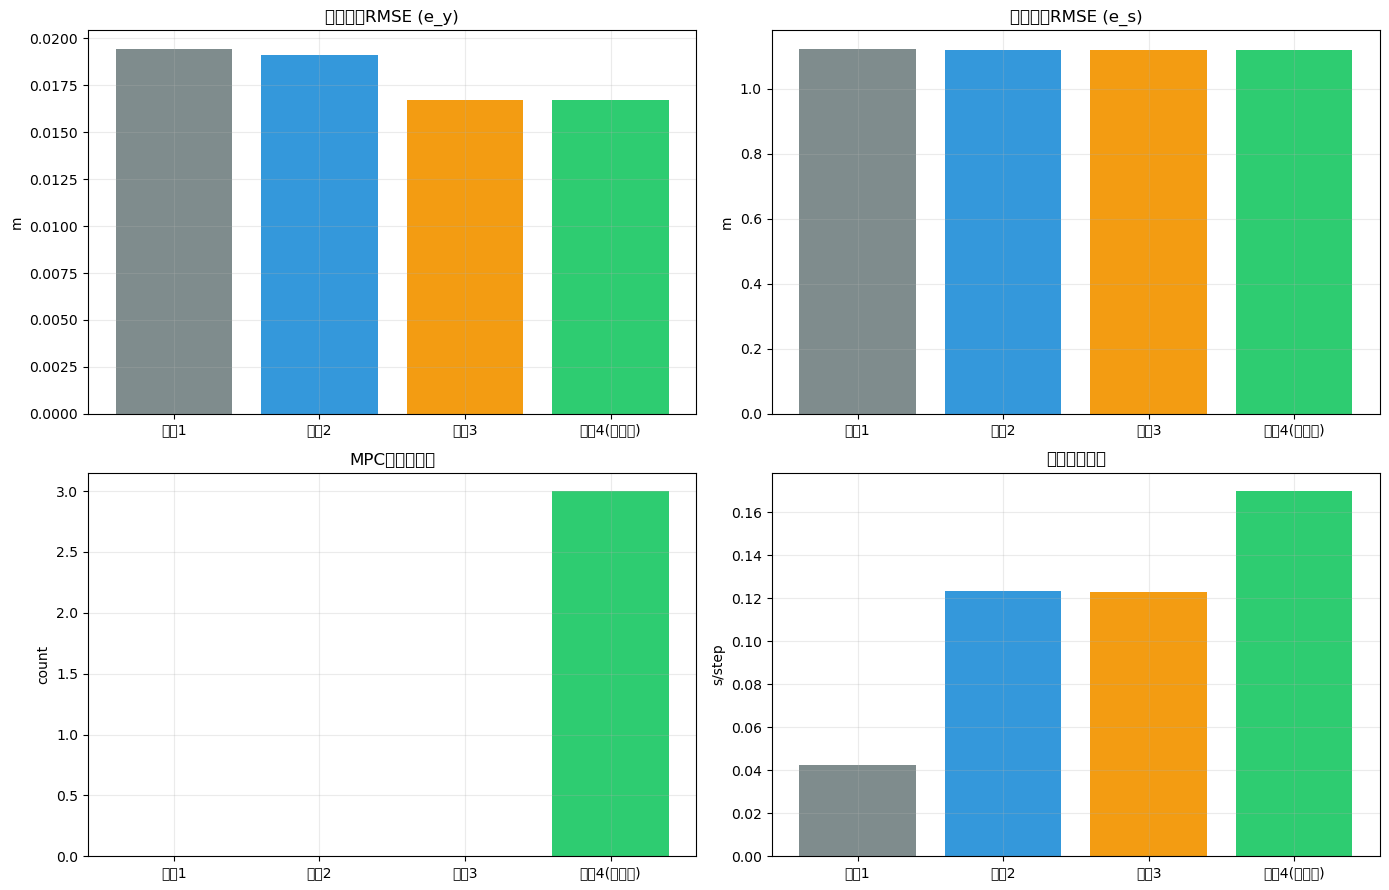

C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:109: UserWarning: Glyph 36710 (\N{CJK UNIFIED IDEOGRAPH-8F66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:109: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:109: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:109: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEOGRAPH-5BF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:109: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:109: UserWarning: Glyph 26041 (\N{CJK UNIFIED IDEO

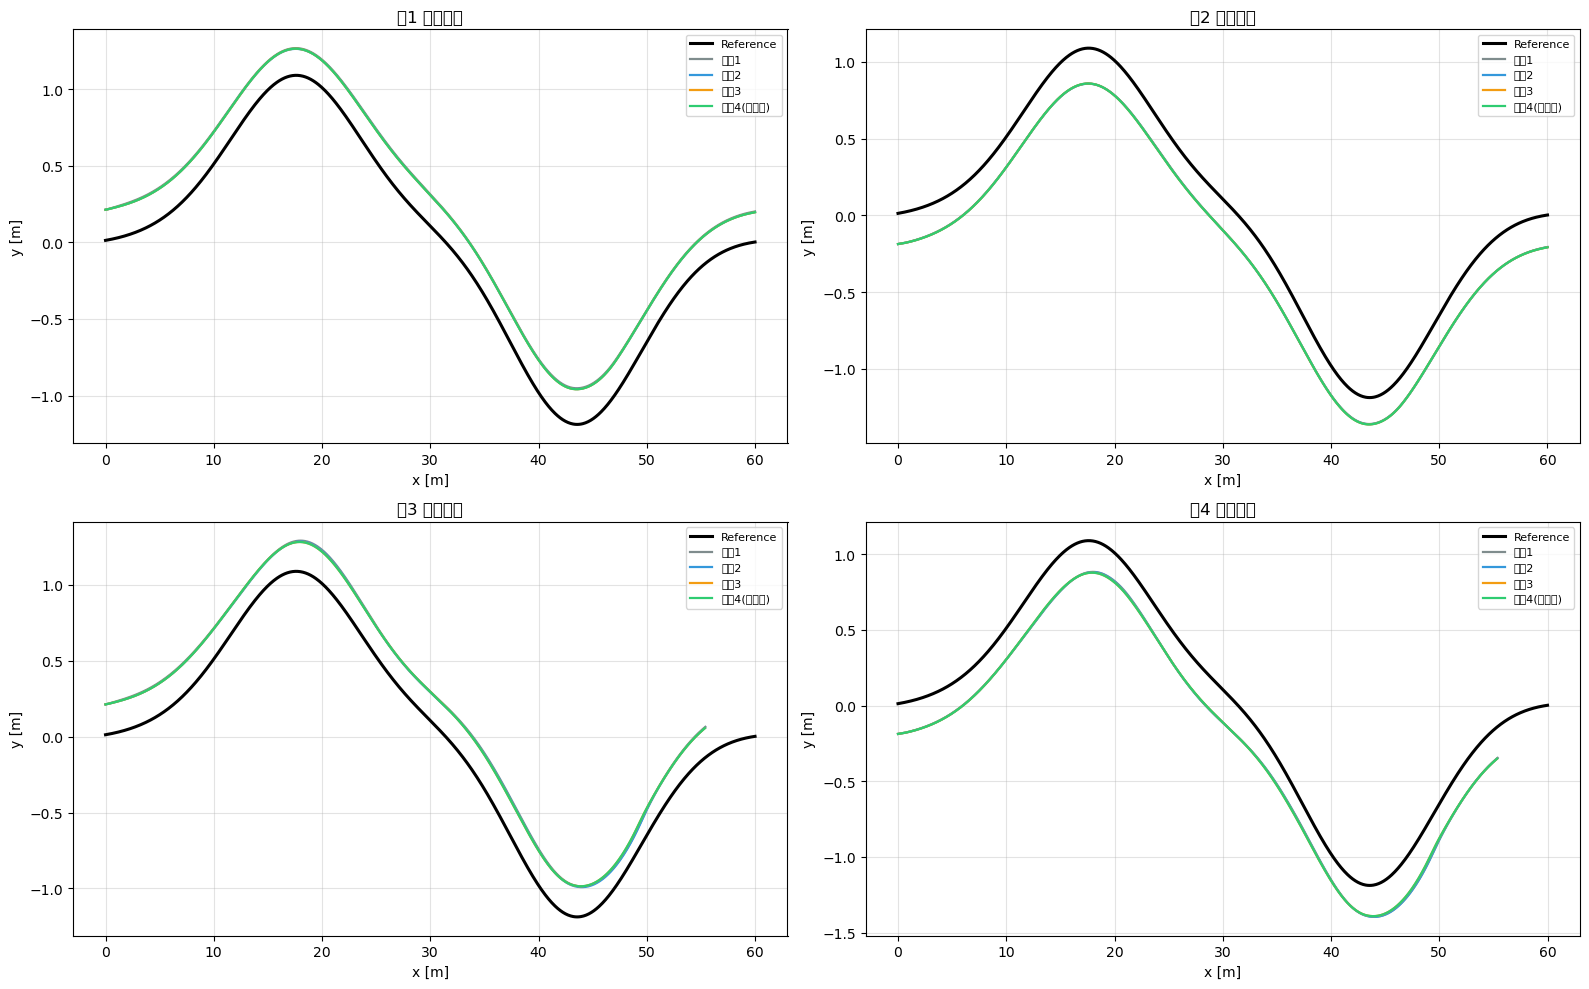


=== 按车RMSE(e_y)矩阵 [方法 x 车辆] ===
[[0.01440563 0.01451042 0.02434096 0.02458305]
 [0.01355598 0.01461356 0.02401625 0.02419359]
 [0.01304872 0.01422531 0.01936019 0.02014186]
 [0.0130425  0.01423025 0.01936749 0.02015459]]

=== 按车RMSE(e_s)矩阵 [方法 x 车辆] ===
[[0.17122904 0.15395403 2.09355779 2.07593169]
 [0.16209131 0.14256445 2.09219025 2.07576674]
 [0.17326032 0.15576835 2.08465604 2.06749623]
 [0.17278272 0.15506824 2.08444236 2.06748892]]


C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:154: UserWarning: Glyph 22235 (\N{CJK UNIFIED IDEOGRAPH-56DB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:154: UserWarning: Glyph 36710 (\N{CJK UNIFIED IDEOGRAPH-8F66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:154: UserWarning: Glyph 36880 (\N{CJK UNIFIED IDEOGRAPH-9010}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:154: UserWarning: Glyph 27178 (\N{CJK UNIFIED IDEOGRAPH-6A2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:154: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_28440\320407378.py:154: UserWarning: Glyph 23545 (\N{CJK UNIFIED IDEO

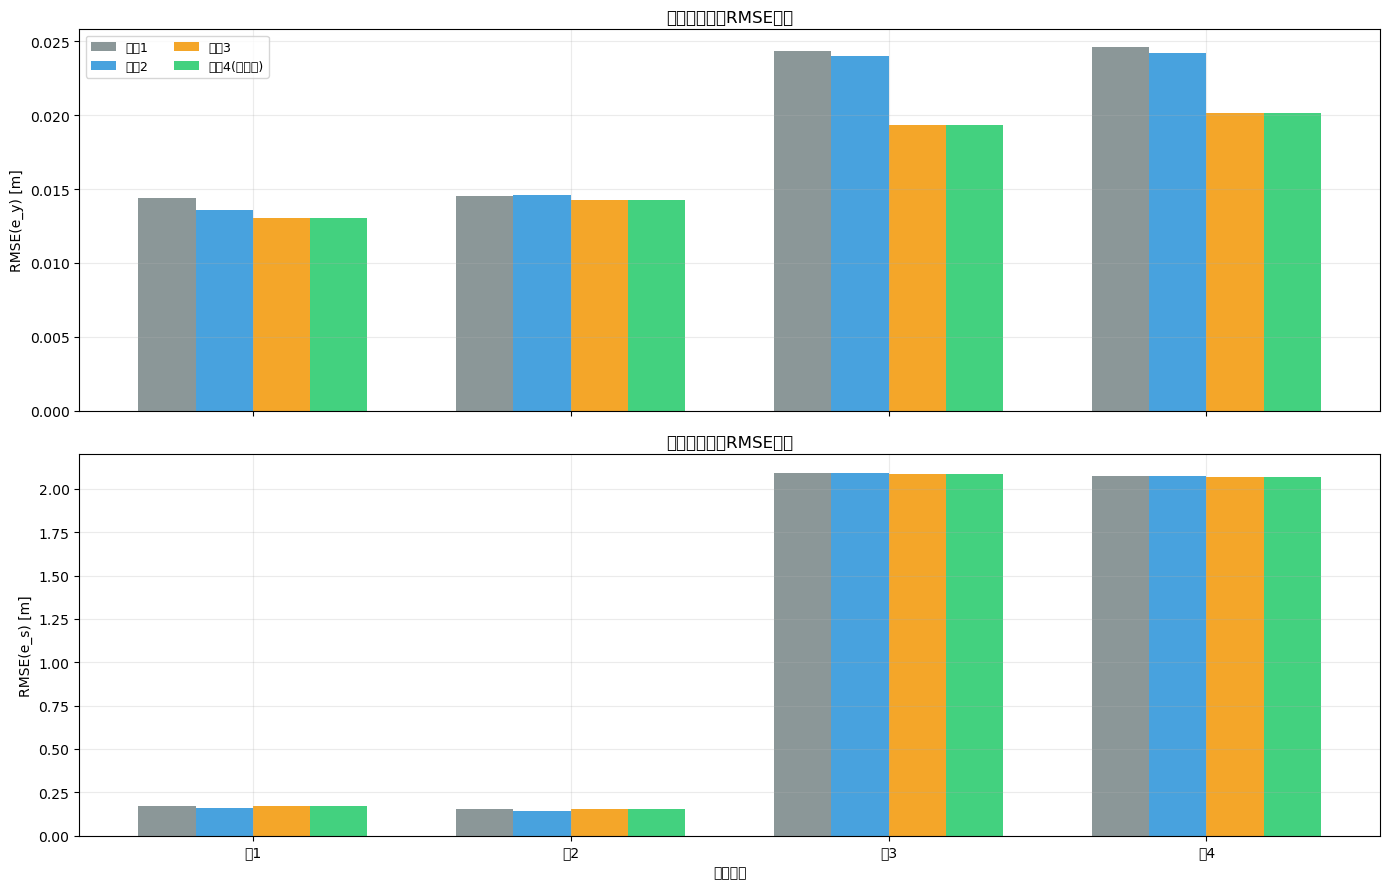

In [12]:
# =========================
# 运行四组对比实验
# =========================
experiment_results = {}

for case in COMPARE_CASES:
    print("\n" + "=" * 80)
    print(f"开始运行: {case['label']}")
    print("=" * 80)
    res = run_single_case(case)
    experiment_results[case["id"]] = res

print("\n所有方法仿真完成。")

# 统一汇总打印
print("\n=== 四方法对比总览 ===")
for case in COMPARE_CASES:
    cid = case["id"]
    r = experiment_results[cid]
    fail_total = int(np.sum(r["fail_counts"]))
    print(
        f"{case['label']} | "
        f"RMSE(e_y)_avg={r['rmse_lat_mean']:.4f} m | "
        f"RMSE(e_s)_avg={r['rmse_long_mean']:.4f} m | "
        f"Max|e_y|={r['max_lat_global']:.4f} m | "
        f"Max|e_s|={r['max_long_global']:.4f} m | "
        f"MPC失败总数={fail_total} | "
        f"平均步耗时={r['avg_step_time']:.4f} s | "
        f"仿真步数={r['sim_steps']} (nom={r.get('sim_steps_nominal', r['sim_steps'])}, cap={r.get('sim_steps_cap', r['sim_steps'])}) | "
        f"全车到达终点={r.get('full_path_reached', False)}"
    )

labels_case = [c["label"].split(":")[0] for c in COMPARE_CASES]
rmse_ey_list = [experiment_results[c["id"]]["rmse_lat_mean"] for c in COMPARE_CASES]
rmse_es_list = [experiment_results[c["id"]]["rmse_long_mean"] for c in COMPARE_CASES]
fail_total_list = [int(np.sum(experiment_results[c["id"]]["fail_counts"])) for c in COMPARE_CASES]
step_time_list = [experiment_results[c["id"]]["avg_step_time"] for c in COMPARE_CASES]

x_pos = np.arange(len(COMPARE_CASES))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].bar(x_pos, rmse_ey_list, color=['#7f8c8d', '#3498db', '#f39c12', '#2ecc71'])
axes[0, 0].set_title('平均横向RMSE (e_y)')
axes[0, 0].set_ylabel('m')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(labels_case)
axes[0, 0].grid(True, alpha=0.25)

axes[0, 1].bar(x_pos, rmse_es_list, color=['#7f8c8d', '#3498db', '#f39c12', '#2ecc71'])
axes[0, 1].set_title('平均纵向RMSE (e_s)')
axes[0, 1].set_ylabel('m')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(labels_case)
axes[0, 1].grid(True, alpha=0.25)

axes[1, 0].bar(x_pos, fail_total_list, color=['#7f8c8d', '#3498db', '#f39c12', '#2ecc71'])
axes[1, 0].set_title('MPC失败总次数')
axes[1, 0].set_ylabel('count')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(labels_case)
axes[1, 0].grid(True, alpha=0.25)

axes[1, 1].bar(x_pos, step_time_list, color=['#7f8c8d', '#3498db', '#f39c12', '#2ecc71'])
axes[1, 1].set_title('平均单步耗时')
axes[1, 1].set_ylabel('s/step')
axes[1, 1].set_xticks(x_pos)
axes[1, 1].set_xticklabels(labels_case)
axes[1, 1].grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

# -------------------------
# 四车逐车对比（路径）
# -------------------------
case_colors = ['#7f8c8d', '#3498db', '#f39c12', '#2ecc71']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for v in range(num_vehicles):
    ax = axes[v]
    ax.plot(x_path, y_ref_path, 'k-', linewidth=2.2, label='Reference')

    for ci, case in enumerate(COMPARE_CASES):
        r = experiment_results[case["id"]]
        sim_steps_case = r.get("sim_steps", traj_length - 1)
        valid_len = min(r["xt_actual_vehicles"][v].shape[0], sim_steps_case + 1)

        s_v = r["xt_actual_vehicles"][v][:valid_len, 0]
        ey_v = r["xt_actual_vehicles"][v][:valid_len, 1]

        s_v = np.clip(s_v, s_ref_path.min() - 10.0, s_ref_path.max() + 10.0)
        x_v, y_v = frenet_to_global(s_v, ey_v, s_ref_path, x_path, y_ref_path, psi_ref_path)

        ax.plot(
            x_v, y_v,
            linewidth=1.6,
            color=case_colors[ci % len(case_colors)],
            label=case["label"].split(':')[0]
        )

    ax.set_title(f'车{v + 1} 轨迹对比')
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.grid(True, alpha=0.35)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# -------------------------
# 四车逐车对比（误差矩阵）
# -------------------------
rmse_lat_matrix = np.zeros((len(COMPARE_CASES), num_vehicles))
rmse_long_matrix = np.zeros((len(COMPARE_CASES), num_vehicles))

for ci, case in enumerate(COMPARE_CASES):
    r = experiment_results[case["id"]]
    for vm in r["vehicle_metrics"]:
        v_idx = vm["vehicle"] - 1
        rmse_lat_matrix[ci, v_idx] = vm["rmse_lat"]
        rmse_long_matrix[ci, v_idx] = vm["rmse_long"]

print("\n=== 按车RMSE(e_y)矩阵 [方法 x 车辆] ===")
print(rmse_lat_matrix)
print("\n=== 按车RMSE(e_s)矩阵 [方法 x 车辆] ===")
print(rmse_long_matrix)

vehicle_labels = [f'车{i+1}' for i in range(num_vehicles)]
width = 0.18
x = np.arange(num_vehicles)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

for ci, case in enumerate(COMPARE_CASES):
    ax1.bar(x + (ci - 1.5) * width, rmse_lat_matrix[ci], width=width,
            color=case_colors[ci % len(case_colors)], alpha=0.9, label=case["label"].split(':')[0])
    ax2.bar(x + (ci - 1.5) * width, rmse_long_matrix[ci], width=width,
            color=case_colors[ci % len(case_colors)], alpha=0.9, label=case["label"].split(':')[0])

ax1.set_title('四车逐车横向RMSE对比')
ax1.set_ylabel('RMSE(e_y) [m]')
ax1.grid(True, alpha=0.25)
ax1.legend(ncol=2, fontsize=9)

ax2.set_title('四车逐车纵向RMSE对比')
ax2.set_ylabel('RMSE(e_s) [m]')
ax2.set_xlabel('车辆编号')
ax2.set_xticks(x)
ax2.set_xticklabels(vehicle_labels)
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()


In [18]:
# =========================
# 主方法结果回填（保持后续单车/四车绘图兼容）
# =========================
MAIN_CASE_ID = "case4_full"
main_result = experiment_results[MAIN_CASE_ID]

xt_actual_vehicles = main_result["xt_actual_vehicles"]
u_vehicles = main_result["u_vehicles"]
z_vehicles = main_result["z_vehicles"]
fail_counts = main_result["fail_counts"]
solver_status_hist = main_result["solver_status_hist"]
terminated_early = main_result["terminated_early"]

begin_time = main_result["begin_time"]
end_linear_noadapt = main_result["end_time"]

print("\n=== 主方法(方法4)统计 ===")
print(f"总仿真时间: {main_result['total_time']:.2f} 秒")
print(f"平均每步时间: {main_result['avg_step_time']:.4f} 秒")
print(f"各车 MPC 失败次数: {fail_counts}")
print(f"提前终止: {terminated_early}")

for vm in main_result["vehicle_metrics"]:
    print(
        f"车{vm['vehicle']}: "
        f"RMSE(e_y)={vm['rmse_lat']:.4f} m, "
        f"RMSE(e_s)={vm['rmse_long']:.4f} m, "
        f"Max|e_y|={vm['max_lat']:.4f} m, "
        f"Max|e_s|={vm['max_long']:.4f} m"
    )

for v in range(num_vehicles):
    status_summary = summarize_solver_status(solver_status_hist[v])
    print(f"车{v+1} OSQP状态统计: {status_summary}")



=== 主方法(方法4)统计 ===
总仿真时间: 169.82 秒
平均每步时间: 0.1698 秒
各车 MPC 失败次数: [1, 2, 0, 0]
提前终止: False
车1: RMSE(e_y)=0.0130 m, RMSE(e_s)=0.1728 m, Max|e_y|=0.0297 m, Max|e_s|=0.3219 m
车2: RMSE(e_y)=0.0142 m, RMSE(e_s)=0.1551 m, Max|e_y|=0.0311 m, Max|e_s|=0.2486 m
车3: RMSE(e_y)=0.0194 m, RMSE(e_s)=2.0844 m, Max|e_y|=0.0557 m, Max|e_s|=5.0000 m
车4: RMSE(e_y)=0.0202 m, RMSE(e_s)=2.0675 m, Max|e_y|=0.0570 m, Max|e_s|=5.0000 m
车1 OSQP状态统计: {'fallback': 1, 'solved': 999}
车2 OSQP状态统计: {'fallback': 2, 'solved': 998}
车3 OSQP状态统计: {'solved': 1000}
车4 OSQP状态统计: {'solved': 1000}


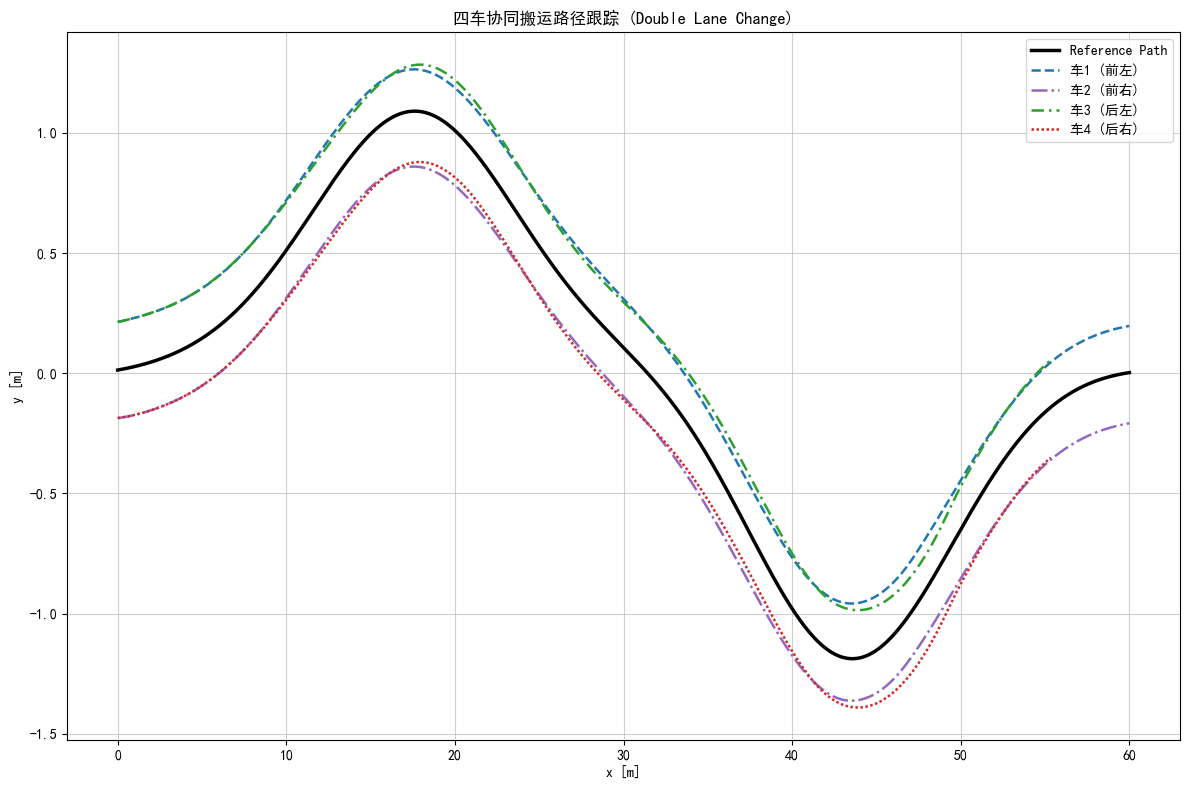


=== 各车轨迹诊断 ===
车1 → 有效步数: 1221/1221 | 最终s位置: 60.46 m
车2 → 有效步数: 1221/1221 | 最终s位置: 60.46 m
车3 → 有效步数: 1221/1221 | 最终s位置: 55.58 m
车4 → 有效步数: 1221/1221 | 最终s位置: 55.53 m


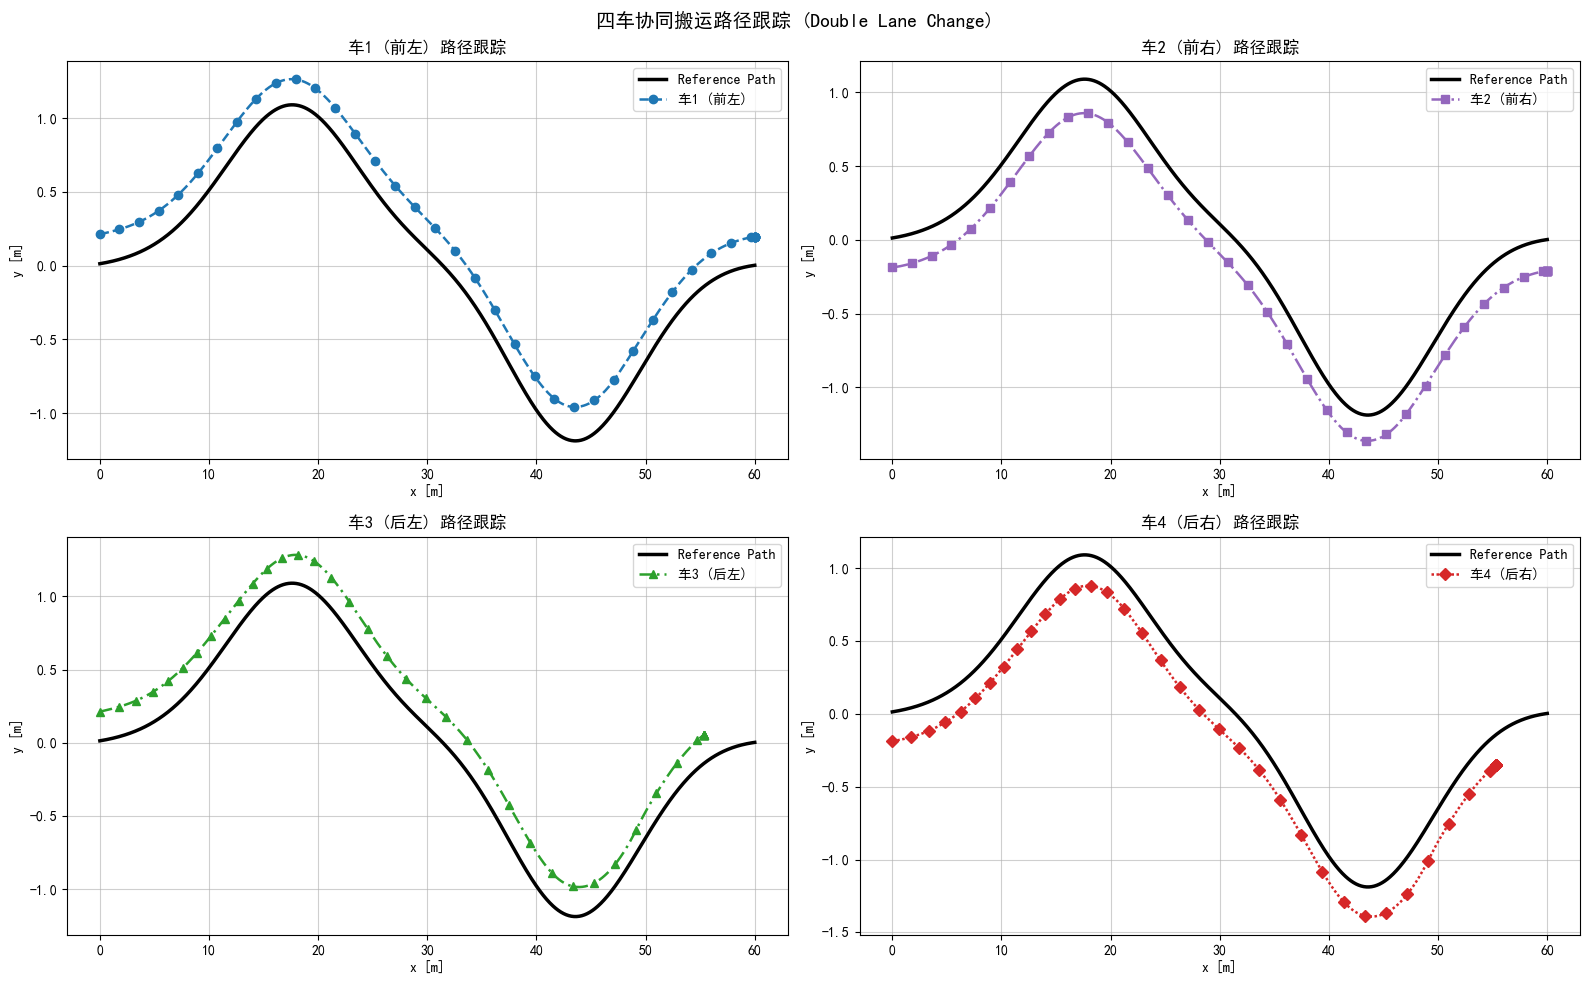


=== 各车轨迹诊断 ===
车1 → 有效步数: 1221/1221 | 最终s位置: 60.46 m
车2 → 有效步数: 1221/1221 | 最终s位置: 60.46 m
车3 → 有效步数: 1221/1221 | 最终s位置: 55.58 m
车4 → 有效步数: 1221/1221 | 最终s位置: 55.53 m


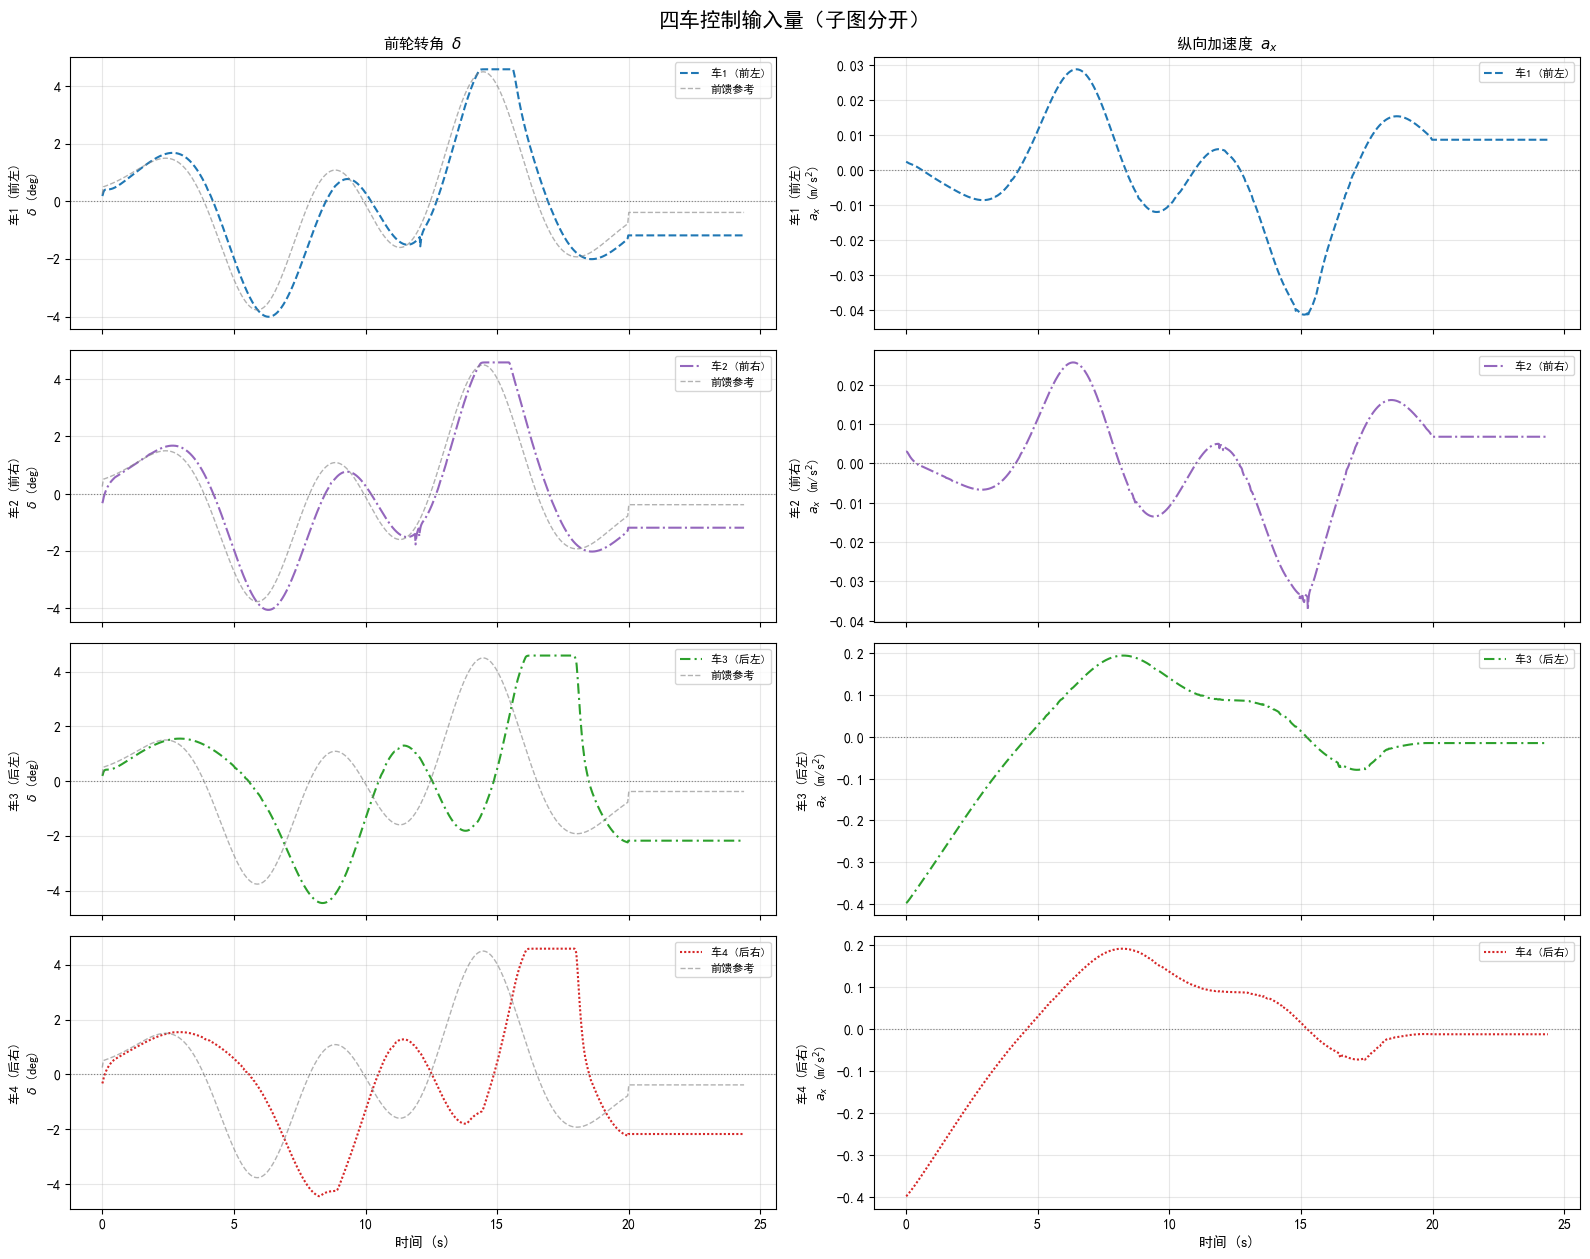

✅ 子图分开版已保存：inputs_separated.png


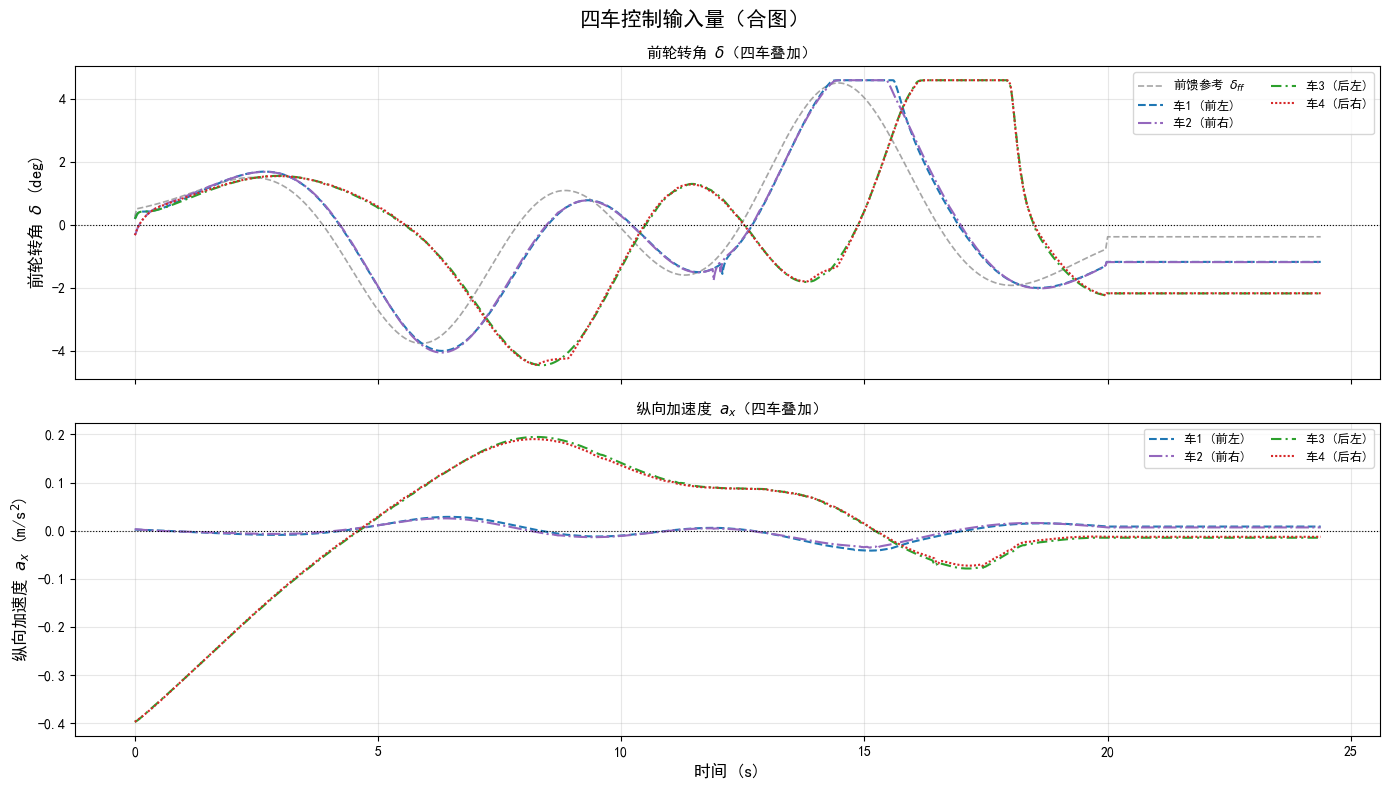

✅ 合图版已保存：inputs_combined.png


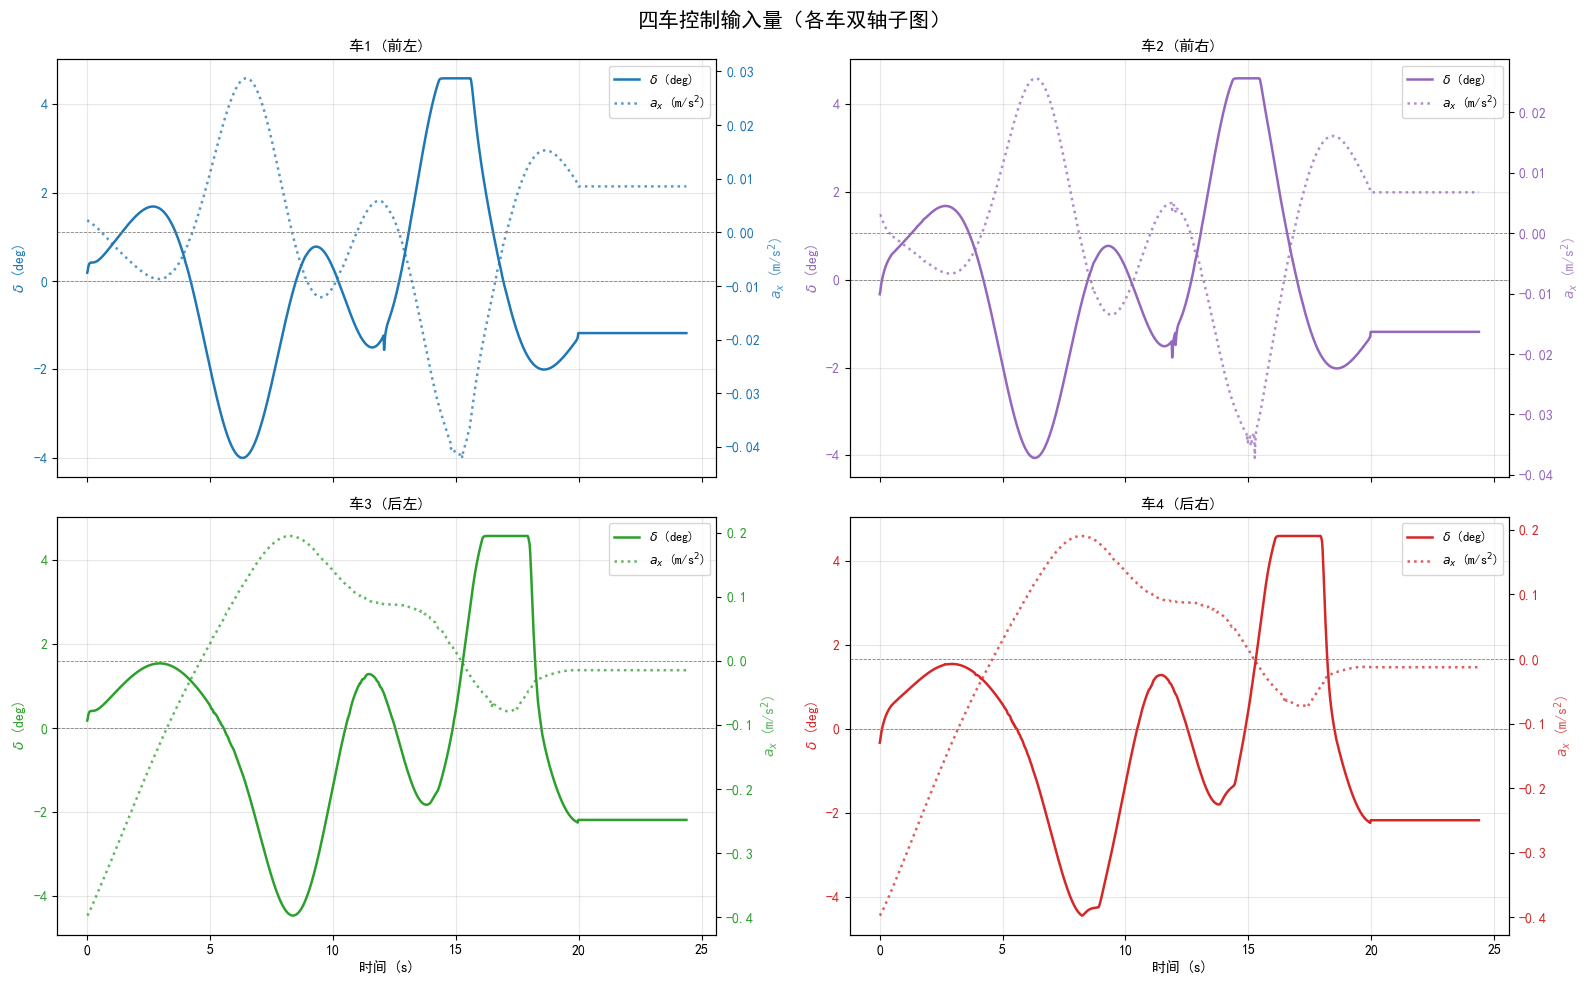

✅ 双轴子图版已保存：inputs_dual_axis.png


In [19]:
# =========================
# Plotting - 四车协同路径跟踪（四车不同线条版）
# =========================
# 解决中文显示问题
import warnings
warnings.filterwarnings("ignore", message="Glyph .* missing from font", category=UserWarning)
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 8))
plt.plot(x_path, y_ref_path, label="Reference Path", linewidth=2.5, color='black')

# 四车不同线条样式（颜色 + 线型组合，更易区分）
styles = [
    {'color': 'tab:blue', 'linestyle': '--', 'marker': 'o', 'linewidth': 1.8, 'label': '车1 (前左)'},
    {'color': 'tab:purple', 'linestyle': '-.', 'marker': 's', 'linewidth': 1.8, 'label': '车2 (前右)'},
    {'color': 'tab:green', 'linestyle': (0, (5, 2, 1, 2)), 'marker': '^', 'linewidth': 1.8, 'label': '车3 (后左)'},
    {'color': 'tab:red', 'linestyle': (0, (1, 1)), 'marker': 'D', 'linewidth': 1.8, 'label': '车4 (后右)'}
]

for v in range(num_vehicles):
    # 更鲁棒的有效长度判断：允许少量非有限值，只取最后一个有效索引
    valid_mask = np.array([is_finite_vector(xt_actual_vehicles[v][idx, :])
                           for idx in range(xt_actual_vehicles[v].shape[0])])

    if not np.any(valid_mask):
        print(f"[WARN] 车{v + 1} 全部状态无效，无轨迹可画")
        continue

    valid_indices = np.where(valid_mask)[0]
    valid_len_v = valid_indices[-1] + 1

    # 提取有效数据
    s_v = xt_actual_vehicles[v][:valid_len_v, 0]
    ey_v = xt_actual_vehicles[v][:valid_len_v, 1]

    # 保护：裁剪s范围，避免插值越界
    s_min = s_ref_path.min() - 10.0
    s_max = s_ref_path.max() + 10.0
    s_v = np.clip(s_v, s_min, s_max)

    # Frenet转全局坐标
    x_v, y_v = frenet_to_global(
        s_v, ey_v,
        s_ref_path, x_path, y_ref_path, psi_ref_path
    )

    # 使用不同线条样式绘制
    plt.plot(x_v, y_v,
             color=styles[v]['color'],
             linestyle=styles[v]['linestyle'],
             linewidth=styles[v]['linewidth'],
             label=styles[v]['label'])

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("四车协同搬运路径跟踪 (Double Lane Change)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

# ====================== 额外诊断信息 ======================
print("\n=== 各车轨迹诊断 ===")
for v in range(num_vehicles):
    valid_count = sum(is_finite_vector(xt_actual_vehicles[v][idx, :])
                      for idx in range(xt_actual_vehicles[v].shape[0]))
    if valid_count > 0:
        last_valid_s_text = f"{xt_actual_vehicles[v][valid_count - 1, 0]:.2f}"
    else:
        last_valid_s_text = "N/A"
    print(f"车{v + 1} → 有效步数: {valid_count}/{xt_actual_vehicles[v].shape[0]} | 最终s位置: {last_valid_s_text} m")
# =========================
# Plotting - 四车协同路径跟踪（四子图版）
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

styles = [
    {'color': 'tab:blue', 'linestyle': '--', 'marker': 'o', 'markevery': 30, 'linewidth': 1.8, 'label': '车1 (前左)'},
    {'color': 'tab:purple', 'linestyle': '-.', 'marker': 's', 'markevery': 30, 'linewidth': 1.8, 'label': '车2 (前右)'},
    {'color': 'tab:green', 'linestyle': (0, (5, 2, 1, 2)), 'marker': '^', 'markevery': 30, 'linewidth': 1.8,
     'label': '车3 (后左)'},
    {'color': 'tab:red', 'linestyle': (0, (1, 1)), 'marker': 'D', 'markevery': 30, 'linewidth': 1.8,
     'label': '车4 (后右)'}
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()  # 变成 [ax0, ax1, ax2, ax3]，方便用索引访问

for v in range(num_vehicles):
    ax = axes[v]

    # 画参考路径（每个子图都画）
    ax.plot(x_path, y_ref_path, label="Reference Path", linewidth=2.5,
            color='black', linestyle='-')

    # 有效长度判断
    valid_mask = np.array([is_finite_vector(xt_actual_vehicles[v][idx, :])
                           for idx in range(xt_actual_vehicles[v].shape[0])])

    if not np.any(valid_mask):
        ax.set_title(f"车{v + 1} - 全部状态无效")
        continue

    valid_indices = np.where(valid_mask)[0]
    valid_len_v = valid_indices[-1] + 1

    s_v = xt_actual_vehicles[v][:valid_len_v, 0]
    ey_v = xt_actual_vehicles[v][:valid_len_v, 1]

    # 裁剪 s 范围
    s_min = s_ref_path.min() - 10.0
    s_max = s_ref_path.max() + 10.0
    s_v = np.clip(s_v, s_min, s_max)

    # Frenet → 全局坐标
    x_v, y_v = frenet_to_global(
        s_v, ey_v,
        s_ref_path, x_path, y_ref_path, psi_ref_path
    )

    # 画该车轨迹
    ax.plot(x_v, y_v,
            color=styles[v]['color'],
            linestyle=styles[v]['linestyle'],
            marker=styles[v]['marker'],
            markevery=styles[v]['markevery'],
            linewidth=styles[v]['linewidth'],
            label=styles[v]['label'])

    ax.set_title(f"{styles[v]['label']} 路径跟踪")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.6)

fig.suptitle("四车协同搬运路径跟踪 (Double Lane Change)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ====================== 诊断信息 ======================
print("\n=== 各车轨迹诊断 ===")
for v in range(num_vehicles):
    valid_count = sum(is_finite_vector(xt_actual_vehicles[v][idx, :])
                      for idx in range(xt_actual_vehicles[v].shape[0]))
    if valid_count > 0:
        last_valid_s_text = f"{xt_actual_vehicles[v][valid_count - 1, 0]:.2f}"
    else:
        last_valid_s_text = "N/A"
    print(f"车{v + 1} → 有效步数: {valid_count}/{xt_actual_vehicles[v].shape[0]} | 最终s位置: {last_valid_s_text} m")
# =========================
# 输入量绘图：前轮转角 & 纵向加速度 (修复字体警告版)
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ── 时间轴 ────────────────────────────────────────────────
# u_vehicles[v] shape: (traj_length-1, 2)
N_ctrl = u_vehicles[0].shape[0]  # 允许大于名义 traj_length - 1
t_ctrl = np.arange(N_ctrl) * dt  # 单位：秒

# 前馈曲率长度与控制时域对齐，避免 x/y 维度不一致
if curvature_ref_path.shape[0] == 0:
    curvature_ff = np.zeros(N_ctrl)
elif curvature_ref_path.shape[0] >= N_ctrl:
    curvature_ff = curvature_ref_path[:N_ctrl]
else:
    curvature_ff = np.pad(curvature_ref_path, (0, N_ctrl - curvature_ref_path.shape[0]), mode='edge')

delta_ff_ref_shared = 0.8 * (sys_pars["lf"] + sys_pars["lr"]) * curvature_ff

# ── 颜色 / 标签 ───────────────────────────────────────────
colors_v = ['tab:blue', 'tab:purple', 'tab:green', 'tab:red']
labels_v = ['车1 (前左)', '车2 (前右)', '车3 (后左)', '车4 (后右)']
ls_v = ['--', '-.', (0, (5, 2, 1, 2)), (0, (1, 1))]

# =========================================================
# 图1：子图分开
# =========================================================
fig1, axes1 = plt.subplots(
    nrows=num_vehicles, ncols=2,
    figsize=(16, 3.2 * num_vehicles),
    sharex=True
)
fig1.suptitle('四车控制输入量（子图分开）', fontsize=15, fontweight='bold')

for v in range(num_vehicles):
    delta_v = u_vehicles[v][:, 0]  # 前轮转角 (rad)
    ax_v = u_vehicles[v][:, 1]  # 纵向加速度 (m/s^2)

    # ── 左列：前轮转角 ─────────────────────────────────
    ax_left = axes1[v, 0]
    ax_left.plot(t_ctrl, np.rad2deg(delta_v),
                 color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                 label=labels_v[v])
    ax_left.axhline(0, color='gray', linewidth=0.8, linestyle=':')

    # 画前馈量（纯参考，供对比）
    delta_ff_ref = delta_ff_ref_shared
    ax_left.plot(t_ctrl, np.rad2deg(delta_ff_ref),
                 color='gray', linewidth=1.0, linestyle='--',
                 alpha=0.6, label='前馈参考')

    ax_left.set_ylabel(f"{labels_v[v]}\n$\\delta$ (deg)", fontsize=9)
    ax_left.legend(fontsize=8, loc='upper right')
    ax_left.grid(True, alpha=0.3)

    if v == 0:
        ax_left.set_title('前轮转角 $\\delta$', fontsize=11)
    if v == num_vehicles - 1:
        ax_left.set_xlabel('时间 (s)', fontsize=10)

    # ── 右列：纵向加速度 ───────────────────────────────
    ax_right = axes1[v, 1]
    ax_right.plot(t_ctrl, ax_v,
                  color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                  label=labels_v[v])
    ax_right.axhline(0, color='gray', linewidth=0.8, linestyle=':')

    ax_right.set_ylabel(f"{labels_v[v]}\n$a_x$ (m/s$^2$)", fontsize=9)
    ax_right.legend(fontsize=8, loc='upper right')
    ax_right.grid(True, alpha=0.3)

    if v == 0:
        ax_right.set_title('纵向加速度 $a_x$', fontsize=11)
    if v == num_vehicles - 1:
        ax_right.set_xlabel('时间 (s)', fontsize=10)

plt.tight_layout()
plt.savefig('inputs_separated.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 子图分开版已保存：inputs_separated.png")

# =========================================================
# 图2：合图
# =========================================================
fig2, (ax_top, ax_bot) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(14, 8),
    sharex=True
)
fig2.suptitle('四车控制输入量（合图）', fontsize=15, fontweight='bold')

# ── 上图：前轮转角 ─────────────────────────────────────
delta_ff_ref = delta_ff_ref_shared
ax_top.plot(t_ctrl, np.rad2deg(delta_ff_ref),
            color='gray', linewidth=1.2, linestyle='--',
            alpha=0.7, label='前馈参考 $\\delta_{ff}$')

for v in range(num_vehicles):
    delta_v = u_vehicles[v][:, 0]
    ax_top.plot(t_ctrl, np.rad2deg(delta_v),
                color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                label=labels_v[v])

ax_top.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax_top.set_ylabel('前轮转角 $\\delta$ (deg)', fontsize=12)
ax_top.legend(loc='upper right', fontsize=9, ncol=2)
ax_top.grid(True, alpha=0.3)
ax_top.set_title('前轮转角 $\\delta$（四车叠加）', fontsize=11)

# ── 下图：纵向加速度 ───────────────────────────────────
for v in range(num_vehicles):
    ax_v = u_vehicles[v][:, 1]
    ax_bot.plot(t_ctrl, ax_v,
                color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                label=labels_v[v])

ax_bot.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax_bot.set_ylabel('纵向加速度 $a_x$ (m/s$^2$)', fontsize=12)
ax_bot.set_xlabel('时间 (s)', fontsize=12)
ax_bot.legend(loc='upper right', fontsize=9, ncol=2)
ax_bot.grid(True, alpha=0.3)
ax_bot.set_title('纵向加速度 $a_x$（四车叠加）', fontsize=11)

plt.tight_layout()
plt.savefig('inputs_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 合图版已保存：inputs_combined.png")

# =========================================================
# 图3：四子图版（每辆车一个子图，delta + ax 双轴）
# =========================================================
fig3, axes3 = plt.subplots(
    nrows=2, ncols=2,
    figsize=(16, 10),
    sharex=True
)
axes3 = axes3.flatten()
fig3.suptitle('四车控制输入量（各车双轴子图）', fontsize=15, fontweight='bold')

for v in range(num_vehicles):
    ax_l = axes3[v]  # 左轴（转角）
    ax_r = ax_l.twinx()  # 右轴（加速度）

    delta_v = np.rad2deg(u_vehicles[v][:, 0])
    accel_v = u_vehicles[v][:, 1]

    l1, = ax_l.plot(t_ctrl, delta_v,
                    color=colors_v[v], linestyle='-', linewidth=1.8,
                    label='$\\delta$ (deg)')
    l2, = ax_r.plot(t_ctrl, accel_v,
                    color=colors_v[v], linestyle=':', linewidth=1.8,
                    alpha=0.75, label='$a_x$ (m/s$^2$)')

    ax_l.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    ax_r.axhline(0, color='gray', linewidth=0.6, linestyle='--')

    ax_l.set_ylabel('$\\delta$ (deg)', fontsize=10, color=colors_v[v])
    ax_r.set_ylabel('$a_x$ (m/s$^2$)', fontsize=10, color=colors_v[v], alpha=0.8)
    ax_l.tick_params(axis='y', labelcolor=colors_v[v])
    ax_r.tick_params(axis='y', labelcolor=colors_v[v])

    ax_l.set_title(labels_v[v], fontsize=11)
    ax_l.grid(True, alpha=0.3)

    lines = [l1, l2]
    labels_leg = [l.get_label() for l in lines]
    ax_l.legend(lines, labels_leg, loc='upper right', fontsize=9)

    if v >= 2:
        ax_l.set_xlabel('时间 (s)', fontsize=10)

plt.tight_layout()
plt.savefig('inputs_dual_axis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 双轴子图版已保存：inputs_dual_axis.png")


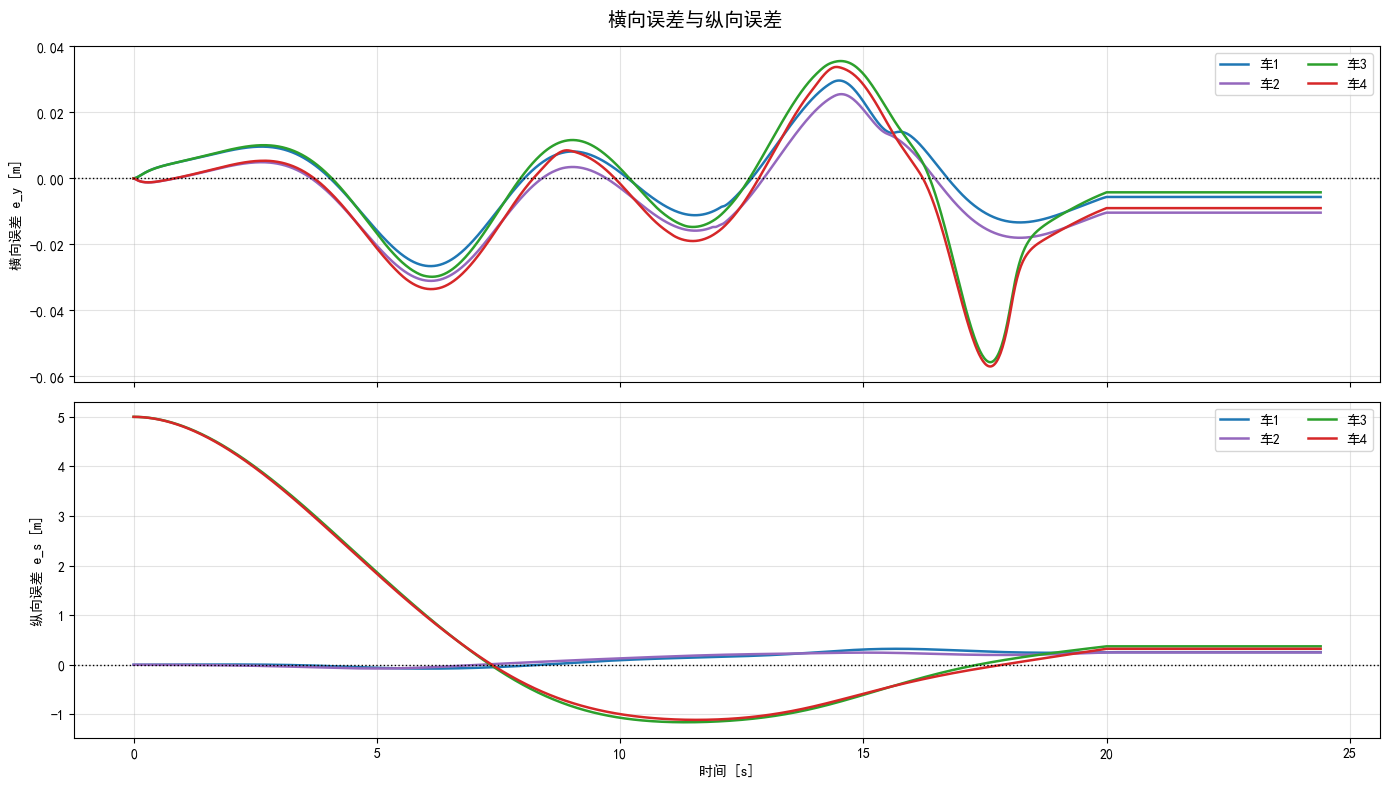

=== 误差统计 ===
车1: RMSE(e_y)=0.0120 m, Max|e_y|=0.0297 m | RMSE(e_s)=0.1899 m, Max|e_s|=0.3219 m
车2: RMSE(e_y)=0.0136 m, Max|e_y|=0.0311 m | RMSE(e_s)=0.1757 m, Max|e_s|=0.2486 m
车3: RMSE(e_y)=0.0176 m, Max|e_y|=0.0557 m | RMSE(e_s)=1.8939 m, Max|e_s|=5.0000 m
车4: RMSE(e_y)=0.0186 m, Max|e_y|=0.0570 m | RMSE(e_s)=1.8770 m, Max|e_s|=5.0000 m


In [20]:
# =========================
# 横向误差 & 纵向误差绘图
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('横向误差与纵向误差', fontsize=14, fontweight='bold')

colors_v = ['tab:blue', 'tab:purple', 'tab:green', 'tab:red']
labels_v = ['车1', '车2', '车3', '车4']

err_stats = []

for v in range(num_vehicles):
    x_hist = xt_actual_vehicles[v]
    n_hist = x_hist.shape[0]
    t_eval = np.arange(n_hist) * dt

    # 每辆车的参考（与闭环中构造 x_ref_raw_v 的逻辑一致）
    s_ref_base = x_ref_raw[0, :] + x0_vehicles[v][0]
    if n_hist <= s_ref_base.shape[0]:
        s_ref_v = s_ref_base[:n_hist]
    else:
        s_ref_v = np.concatenate([s_ref_base, np.full(n_hist - s_ref_base.shape[0], s_ref_base[-1])])
    ey_ref_v = np.full(n_hist, x0_vehicles[v][1])

    e_long = x_hist[:, 0] - s_ref_v  # 纵向误差 e_s
    e_lat = x_hist[:, 1] - ey_ref_v  # 横向误差 e_y

    valid = np.isfinite(e_long) & np.isfinite(e_lat)
    if not np.any(valid):
        print(f"车{v+1}: 无有效误差数据")
        continue

    c = colors_v[v % len(colors_v)]
    label = labels_v[v] if v < len(labels_v) else f'车{v+1}'

    ax1.plot(t_eval[valid], e_lat[valid], color=c, linewidth=1.8, label=label)
    ax2.plot(t_eval[valid], e_long[valid], color=c, linewidth=1.8, label=label)

    rmse_lat = float(np.sqrt(np.mean(e_lat[valid] ** 2)))
    rmse_long = float(np.sqrt(np.mean(e_long[valid] ** 2)))
    max_lat = float(np.max(np.abs(e_lat[valid])))
    max_long = float(np.max(np.abs(e_long[valid])))

    err_stats.append((v + 1, rmse_lat, max_lat, rmse_long, max_long))

ax1.axhline(0.0, color='black', linestyle=':', linewidth=1.0)
ax2.axhline(0.0, color='black', linestyle=':', linewidth=1.0)

ax1.set_ylabel('横向误差 e_y [m]')
ax2.set_ylabel('纵向误差 e_s [m]')
ax2.set_xlabel('时间 [s]')

ax1.grid(True, alpha=0.35)
ax2.grid(True, alpha=0.35)
ax1.legend(loc='upper right', ncol=min(2, num_vehicles))
ax2.legend(loc='upper right', ncol=min(2, num_vehicles))

plt.tight_layout()
plt.show()

print("=== 误差统计 ===")
for vid, rmse_lat, max_lat, rmse_long, max_long in err_stats:
    print(
        f"车{vid}: "
        f"RMSE(e_y)={rmse_lat:.4f} m, Max|e_y|={max_lat:.4f} m | "
        f"RMSE(e_s)={rmse_long:.4f} m, Max|e_s|={max_long:.4f} m"
    )

